# BTSP on a linear track

**Objective:** Compare hyperparameters and evaluate spatial features pyramidal neurons learn to encode.

* Linear track (periodic)
* Agent navigates in a specific direction (and eventually back and forth)
* Target object located partway along the track.
* Two-compartment pyramidal neuron layer:
  * Somatic input: uniformly distributed Gaussian place cells (plastic)
  * Dendritic input: Target object-encoding cell (fixed)
  * Filtered dendritic self-inhibition
  * 1 pyramidal neuron only
* Learning:
  * BTSP learning: strong learning with a broad kernel, occurring when a neuron's activation passes a predetermined threshold.

In [1]:
import copy
import importlib
from pathlib import Path
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, plot_fcts, run_manager
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons
from predhpc.util import ext_util, plot_util, params_util, animate_util, gen_util, learn_util

%load_ext autoreload

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = str(Path("figures", "linear_track"))

ALL_FIGURES = dict()

In [3]:
warnings.filterwarnings(
    "ignore", message="solid 1D boundary", category=UserWarning
)
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [4]:
%autoreload 2

## Hyperparameters and functions

In [5]:
NUM_STEPS = 3800
USE_HEBBIAN = False

target_position = np.asarray([params_util.SCALE_LINEAR / 3])
moved_target_position = np.asarray([params_util.SCALE_LINEAR * 2 / 3])

agent_params = params_util.get_agent_params(
    environment="linear",
    target_position=target_position,
    wait_at_end=int(10 / params_util.DT)
)

Pyr_params = params_util.get_Pyr_params(
    environment="linear",
)

## 1. Initial direction

100%|██████████████████████████████████████| 3800/3800 [00:04<00:00, 860.10it/s]


Finishing last trajectory.


906it [00:01, 814.69it/s]


Only reached target 5 times (target: 10).
Trajectory lengths (6) to date: 23.54 +/- 11.05 sec each
Trajectory lengths (6) to date: 784.50 +/- 368.24 steps each
1 BTSP events triggered (allowed from steps 0 to 4706): occurred at step 246.


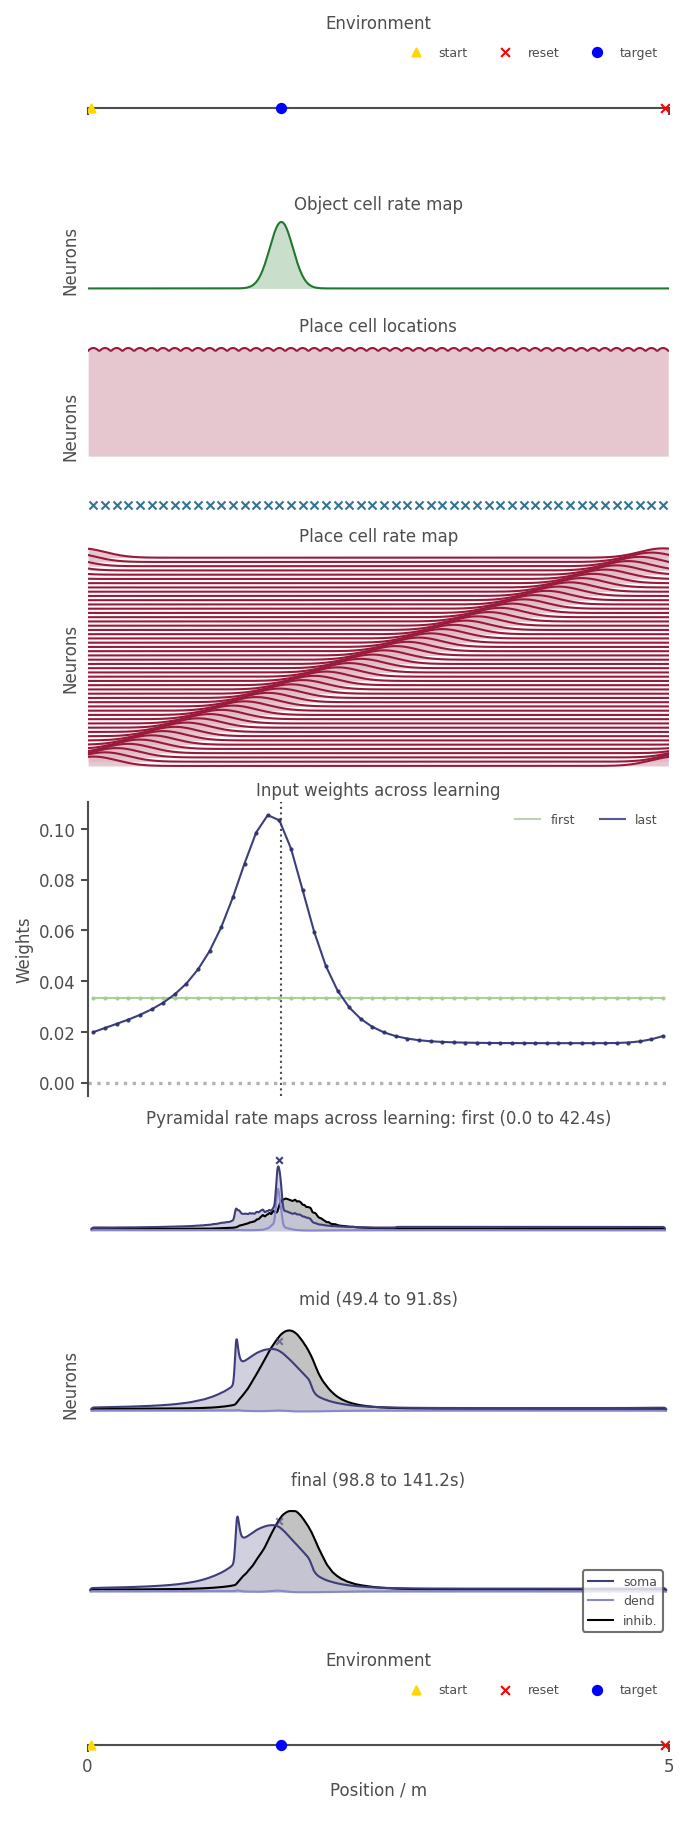

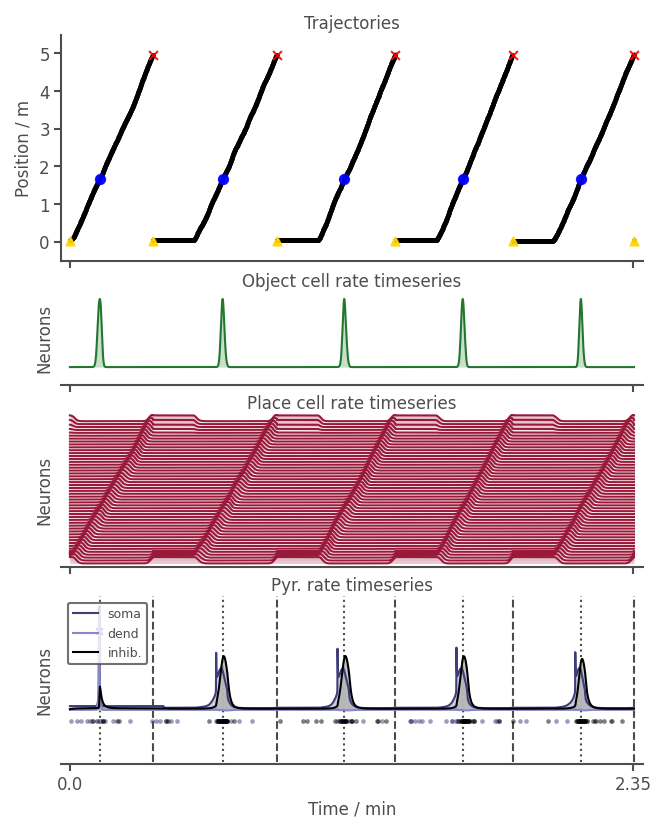

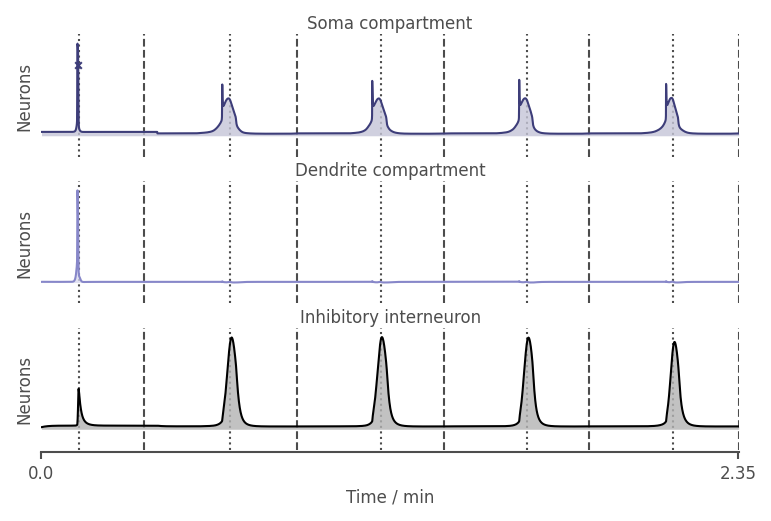

In [6]:
learner, spatial_axes, time_axes = run_manager.learn_1D_BTSP(
    agent_params=agent_params,
    Pyr_params=Pyr_params,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
)

Pyrs = learner.Pyrs
Env, Ag, PCs, Objs = ext_util.extract_objects_from_Pyrs(Pyrs)

ts_axes = learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["1-initial_spatial"] = spatial_axes
ALL_FIGURES["1-initial_time"] = time_axes
ALL_FIGURES["1-initial_timeseries"] = ts_axes

In [7]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP(stats_only=True)
learner.Pyrs.SomaCompartment.log_BTSP_applied_then_triggered_interval(shortest=True)

BTSP events applied after 537.00 steps (16.11 sec.)
No neuron had at least two BTSP events triggered.


Speed mean: 24.43 cm/s, std: 4.13 cm/s.


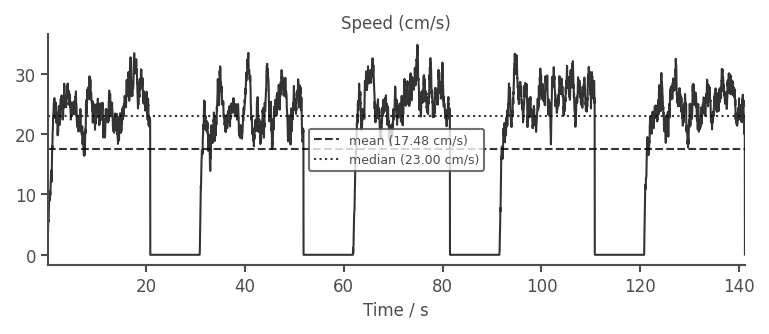

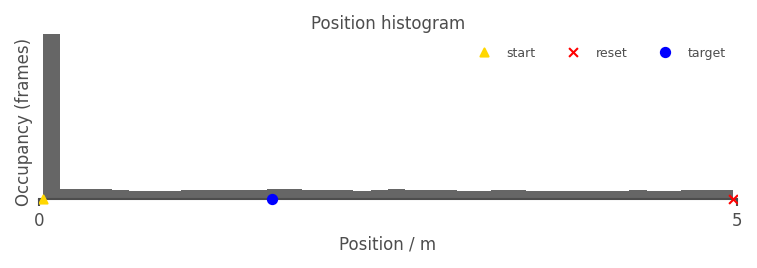

In [8]:
learner.Agent.log_speed_stats(ignore_near_zero=True)
sub_ax_speed = learner.Agent.plot_speed(mark_median=True, mark_mean=True)
sub_ax_occ = learner.Agent.plot_occupancy()

ALL_FIGURES["1-single_speed"] = sub_ax_speed
ALL_FIGURES["1-single_occupancy"] = sub_ax_occ

### Initial direction track groundtruth rate maps

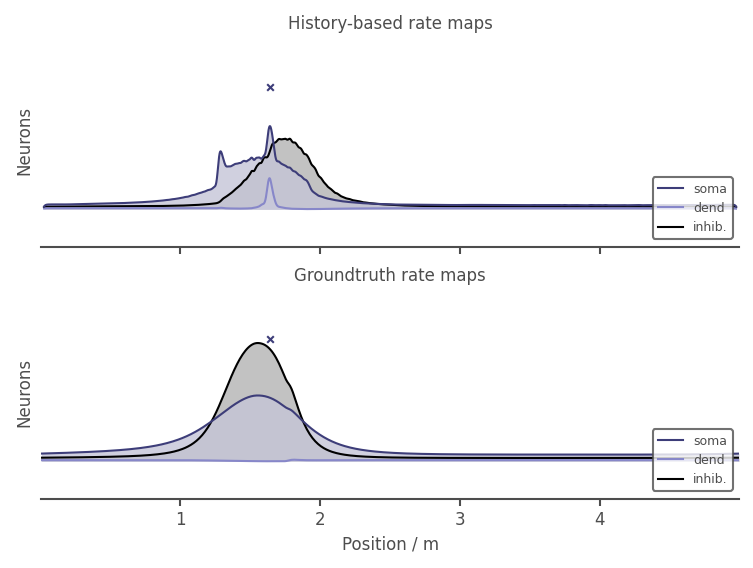

In [9]:
_, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps");

ALL_FIGURES["1-initial_rate_maps"] = ax1D

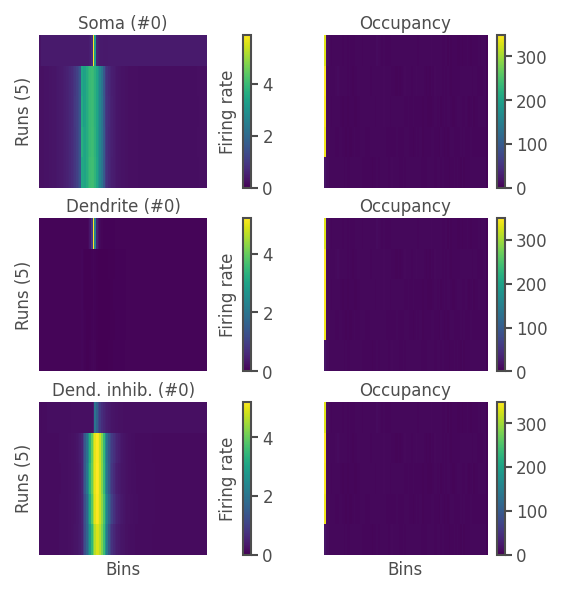

In [10]:
axes = learner.Pyrs.plot_binned_rates()

ALL_FIGURES["1-initial_binned_rates"] = axes

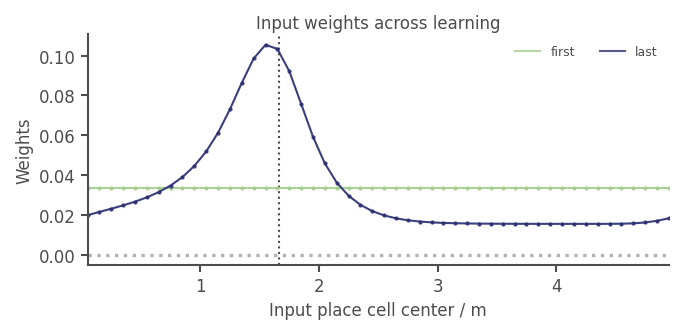

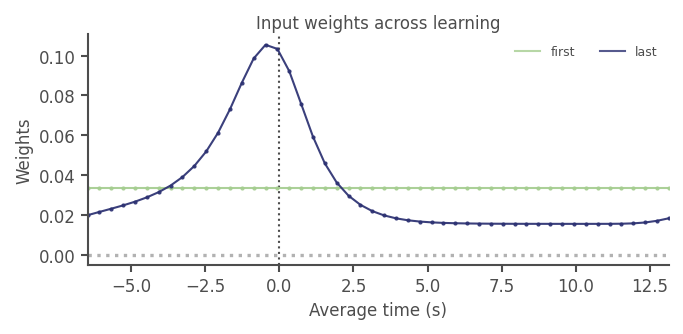

In [11]:
ws = [learner.Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"])
sub_ax_time = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"], time_axis=True)

ALL_FIGURES["1-initial_weights"] = sub_ax
ALL_FIGURES["1-initial_weights_time"] = sub_ax_time

### Assessments based on theoretical kernel

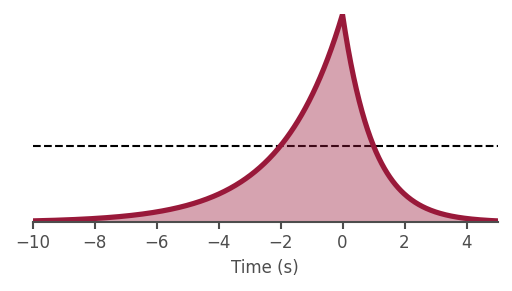

In [12]:
sub_ax_exp_kernel, _ = plot_util.plot_pre_post_exponential(
    dt=learner.Agent.dt, 
    filter_tau=learner.Pyrs.SomaCompartment.BTSP_filter_tau,
    post_filter_tau=learner.Pyrs.SomaCompartment.post_BTSP_filter_tau,
    color=PCs.color, 
    xlims=[-10, 5], 
)
ALL_FIGURES["BTSP_exp_kernel"] = sub_ax_exp_kernel

Update 1 regul.: 2.3084 (w)


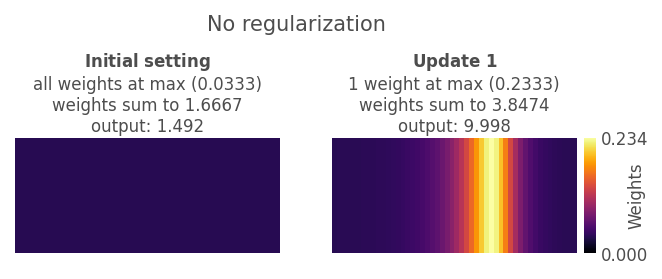

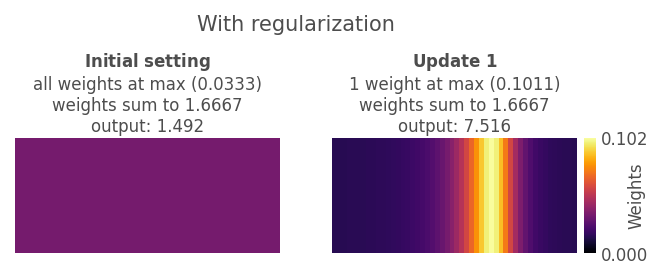

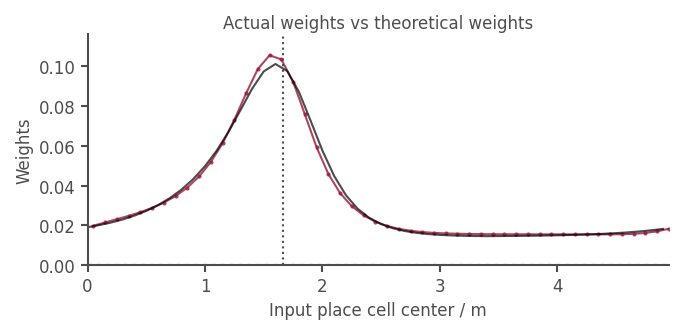

In [13]:
OUTPUT_FR = 5 # tuned to match actual weights as closely as possible

for normalize_weights_divisively in [False, True]:
    assessment_dict = learn_util.assess_Pyrs_lr_factors(
        learner.Pyrs.SomaCompartment, 
        normalize_weights_divisively=normalize_weights_divisively, 
        output_fr=OUTPUT_FR, 
        log_reg=True,
    )
    axes = plot_util.plot_lr_factor_assessment(assessment_dict)
    title_str = "With" if normalize_weights_divisively else "No"
    axes.ravel()[0].figure.suptitle(f"{title_str} regularization", y=1.7)
    norm_str = "_norm" if normalize_weights_divisively else ""
    ALL_FIGURES[f"BTSP_kernel{norm_str}"] = axes

ws = learner.Pyrs.SomaCompartment.inputs["PCs"]["w"]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, learner.Pyrs.SomaCompartment.inputs["PCs"]["layer"])

w = assessment_dict["ws"][-1][:, 0]
x = np.linspace(0, learner.Pyrs.SomaCompartment.Agent.Environment.scale, len(w) + 1)[:-1]
peak_pt_diff = np.argmax(w) - len(w) // 3
sub_ax.plot(x, np.roll(w, -peak_pt_diff), color="k", alpha=0.7)
sub_ax.set_title("Actual weights vs theoretical weights")
sub_ax.autoscale(axis="y")
plot_util.pad_axis(sub_ax, axis="y", end="high")

ALL_FIGURES["1-initial_weights_compared"] = sub_ax

### Initial direction inputs and activations

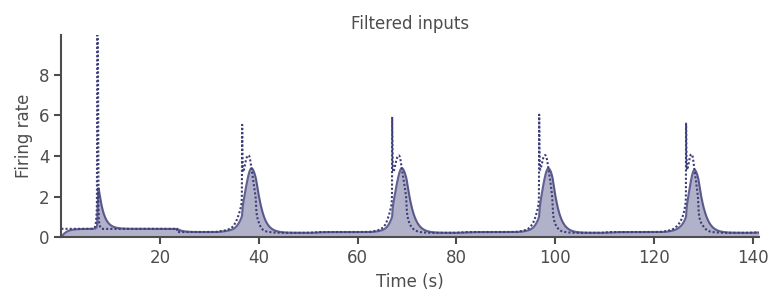

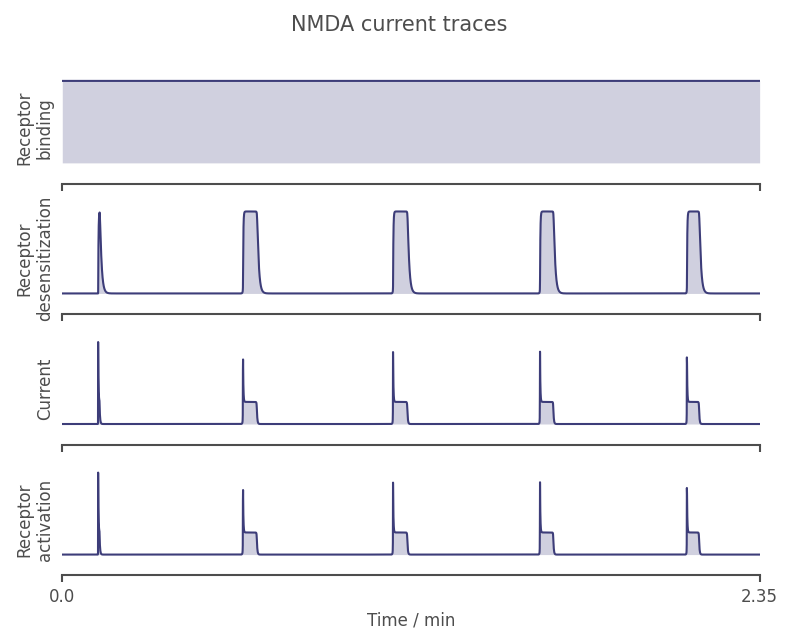

In [14]:
sub_ax, _ = learner.Pyrs.DendriteInhibition.plot_filtered("Pyr_TwoComp_soma")
ax1D = learner.Pyrs.SomaCompartment.NMDACurrent.plot_timeseries(datatypes="all")

ALL_FIGURES["1-initial_filtered_inputs"] = sub_ax
ALL_FIGURES["1-initial_NMDA_current"] = ax1D

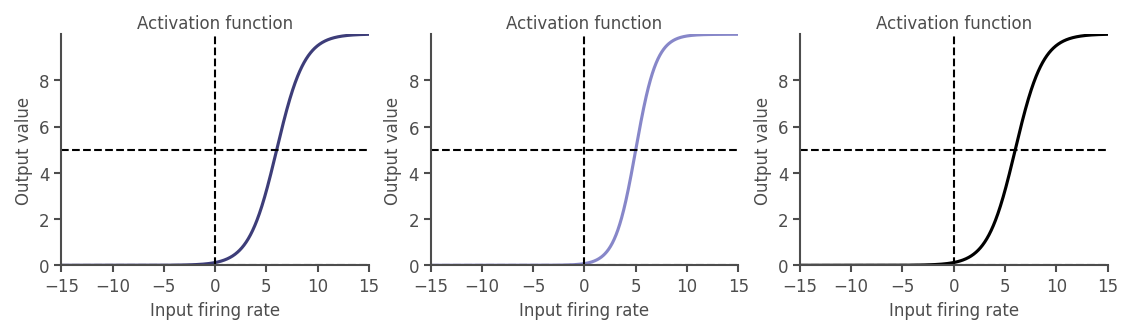

In [15]:
fig, ax1D = plt.subplots(1, 3, figsize=[9, 2])
learner.Pyrs.SomaCompartment.plot_activation_function(sub_ax=ax1D[0])
learner.Pyrs.DendriteCompartment.plot_activation_function(sub_ax=ax1D[1])
learner.Pyrs.DendriteInhibition.plot_activation_function(sub_ax=ax1D[2])

ALL_FIGURES["activation"] = ax1D

### Initial direction BTSP stats

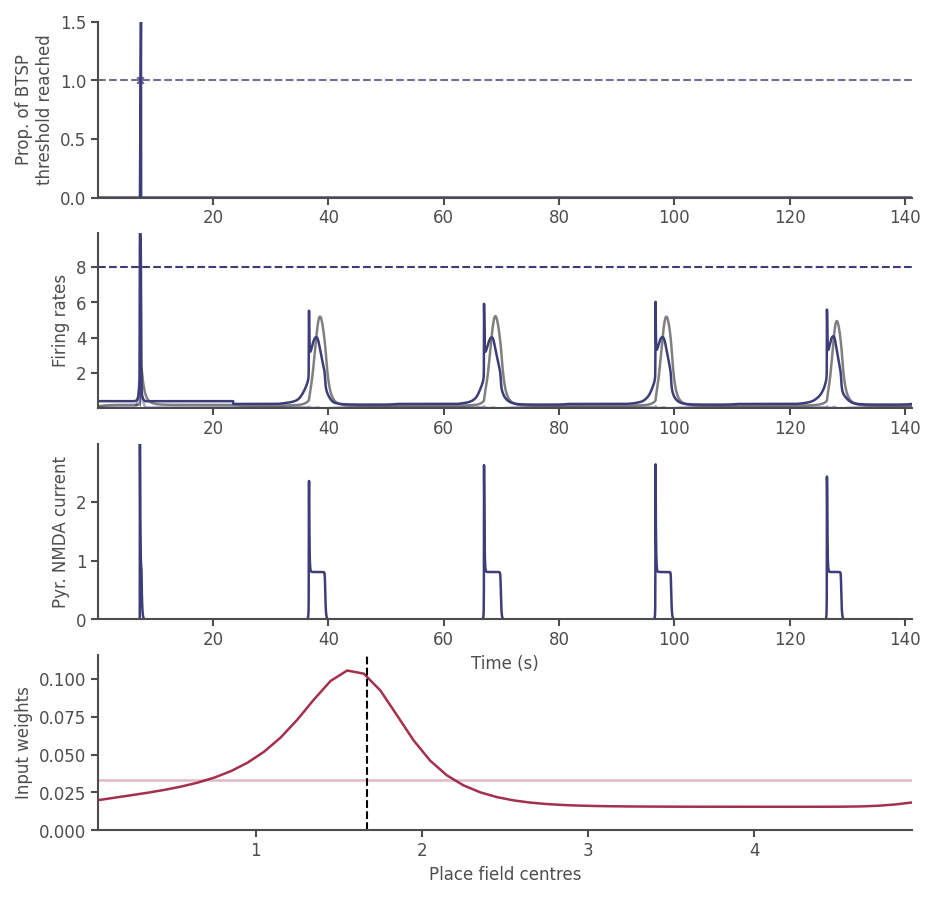

In [16]:
ax1D = plot_fcts.plot_1D_BTSP_stats(
    learner.Pyrs, 
    recorded_weights=learner.get_recorded_weights(), 
    target_position=target_position
)

ALL_FIGURES["1-initial_BTSP_timeseries"] = ax1D

### Pre BTSP kernel

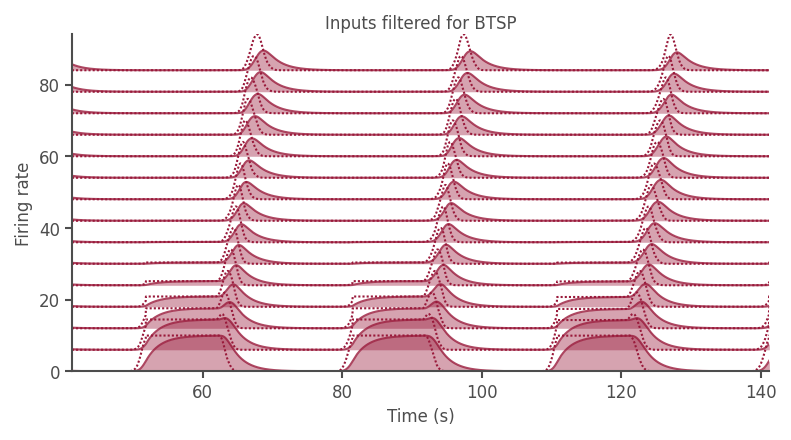

In [17]:
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP("PCs", t_start=-100, chosen_neurons=np.arange(15))
ALL_FIGURES["1-initial_pre_BTSP_filter"] = sub_ax

### Post BTSP kernel

BTSP events applied after 537.00 steps (16.11 sec.) (num steps: 537).


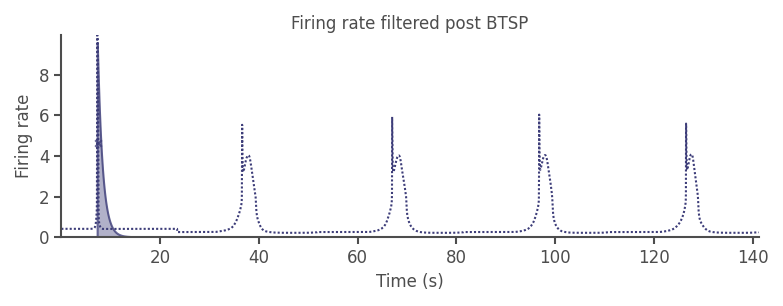

In [18]:
learner.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["1-initial_post_BTSP_filter"] = sub_ax

## 2. Move target
Target moved to a new location after initial BTSP learning.

100%|██████████████████████████████████████| 3800/3800 [00:04<00:00, 871.57it/s]


Finishing last trajectory.


242it [00:00, 453.41it/s]


Only reached target 4 times (target: 10).
Trajectory lengths (10) to date: 26.25 +/- 9.20 sec each
Trajectory lengths (10) to date: 875.00 +/- 306.71 steps each
1 BTSP events triggered (allowed from steps 4707 to 8749): occurred at step 5529.


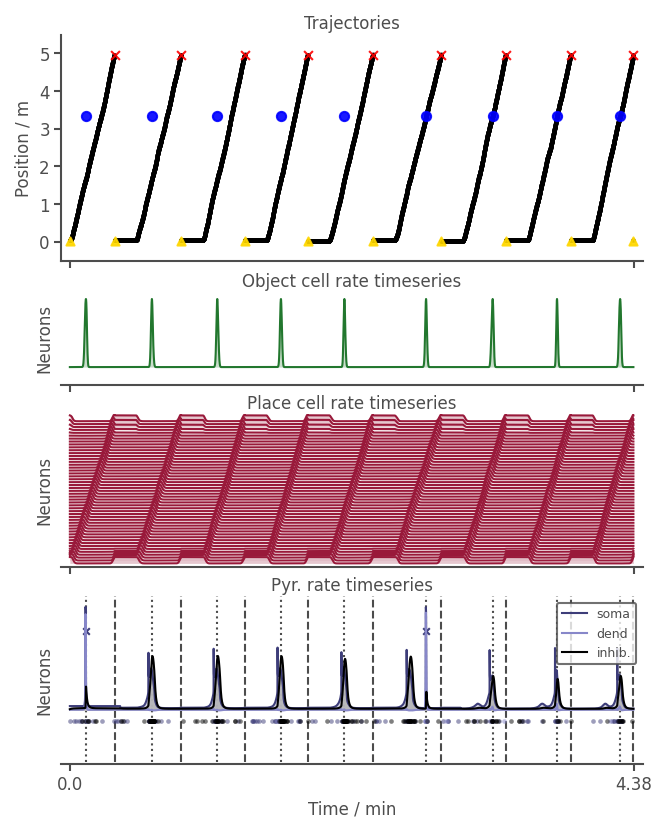

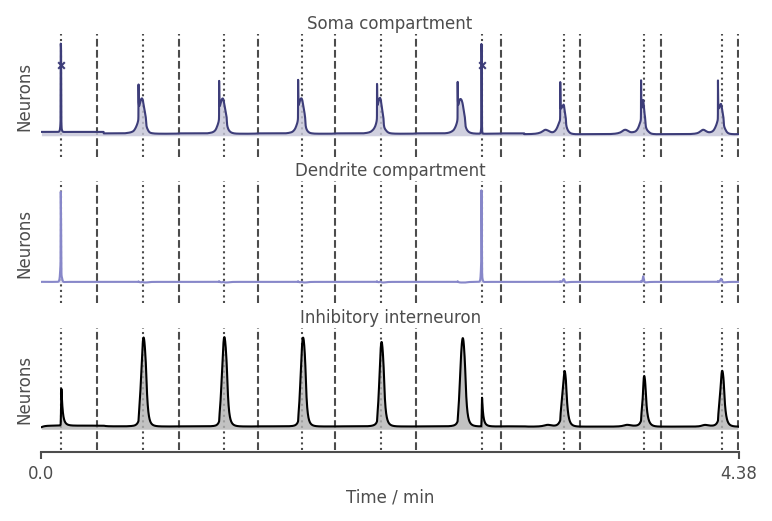

In [19]:
move_time = Ag.t
Ag.set_target_position(moved_target_position)

learner_moved = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_moved.Pyrs)
ts_axes = learner_moved.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["2-moved_time"] = time_axes
ALL_FIGURES["2-moved_timeseries"] = ts_axes

### Moved target groundtruth rate maps

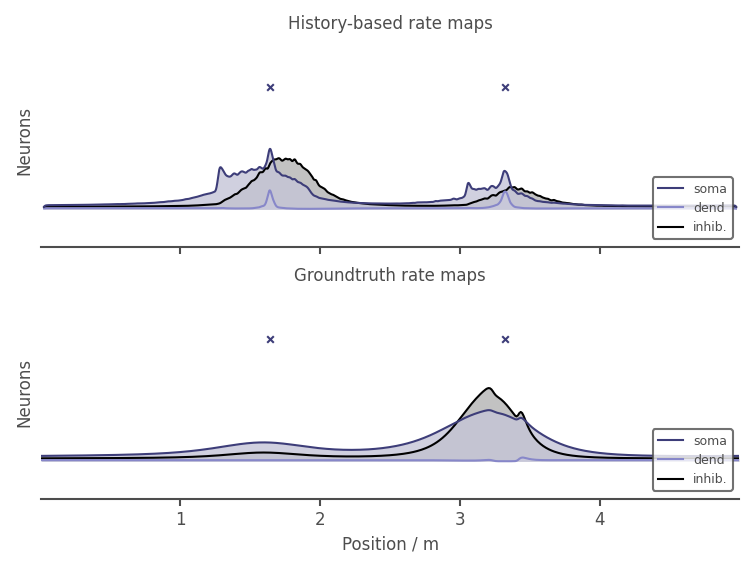

In [20]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_moved.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_moved.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["2-moved_rate_maps"] = ax1D

### Moved target BTSP stats

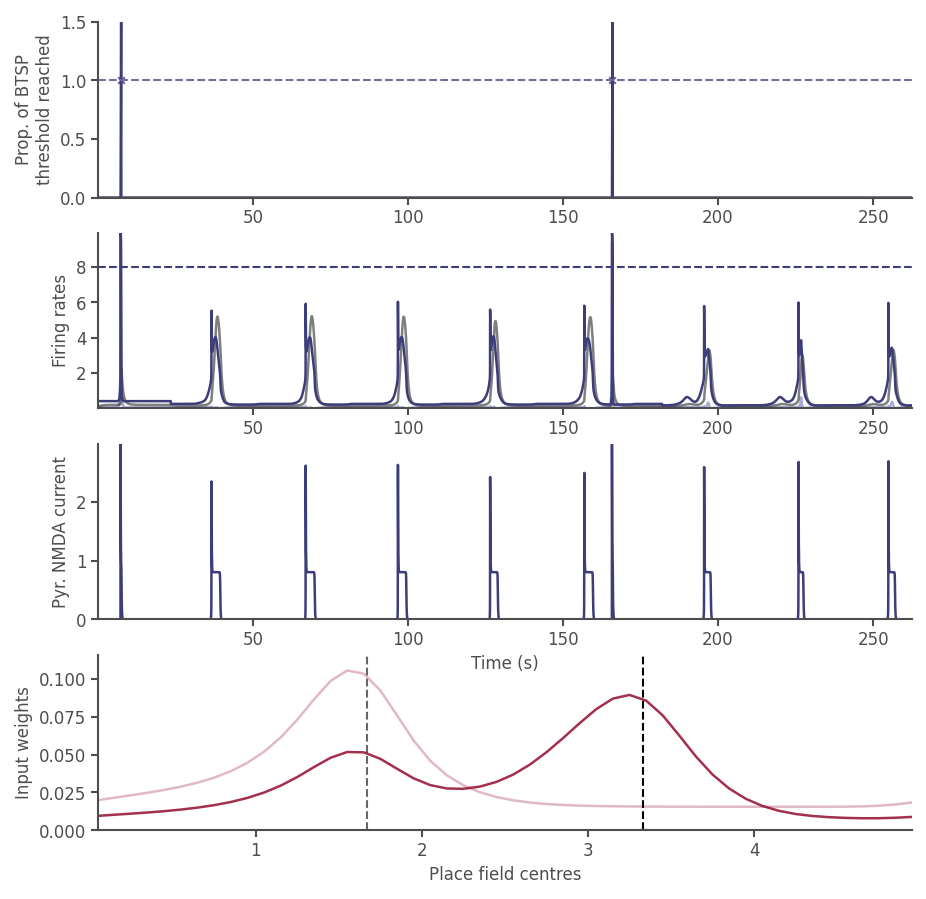

In [21]:
ax1D = plot_fcts.plot_1D_BTSP_stats(
    learner_moved.Pyrs, 
    recorded_weights=learner_moved.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["2-moved_BTSP_timeseries"] = ax1D

BTSP events applied after 537.00 steps (16.11 sec.) (num steps: 537, 537).


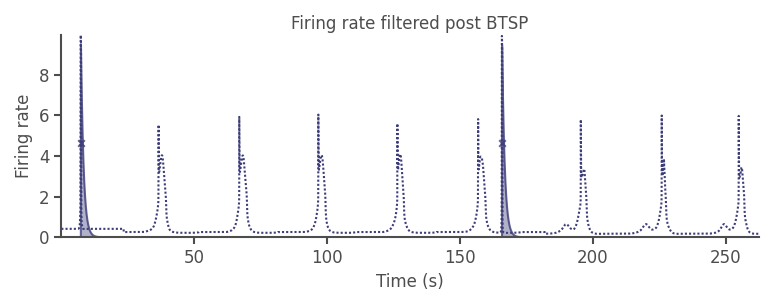

In [22]:
learner_moved.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_moved.Pyrs.SomaCompartment.plot_filtered_for_BTSP()
ALL_FIGURES["2-moved_post_BTSP_filter"] = sub_ax

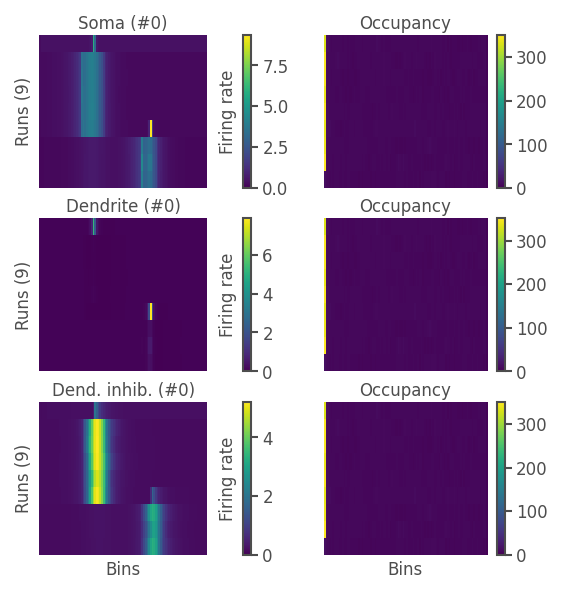

In [23]:
axes = learner_moved.Pyrs.plot_binned_rates()
ALL_FIGURES["2-moved_binned_rates"] = axes

## 3. Switch to back and forth navigation
Agent set to travel back and forth along the track.

100%|██████████████████████████████████████| 7600/7600 [00:09<00:00, 843.00it/s]


Finishing last trajectory.


2587it [00:02, 936.94it/s] 


Reached target 10 times.
Trajectory lengths (20) to date: 28.41 +/- 6.89 sec each
Trajectory lengths (20) to date: 946.90 +/- 229.65 steps each
1 BTSP events triggered (allowed from steps 8750 to 18937): occurred at step 10335.


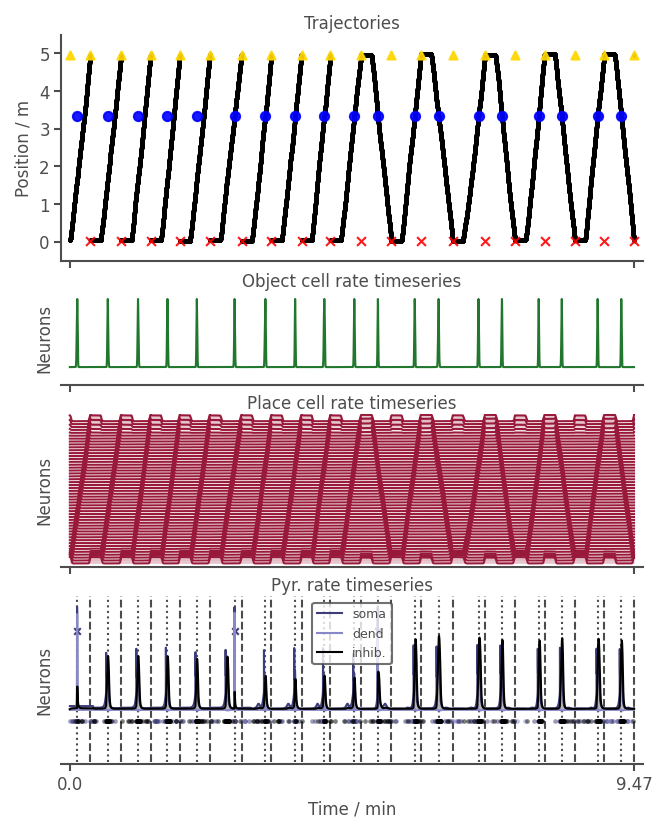

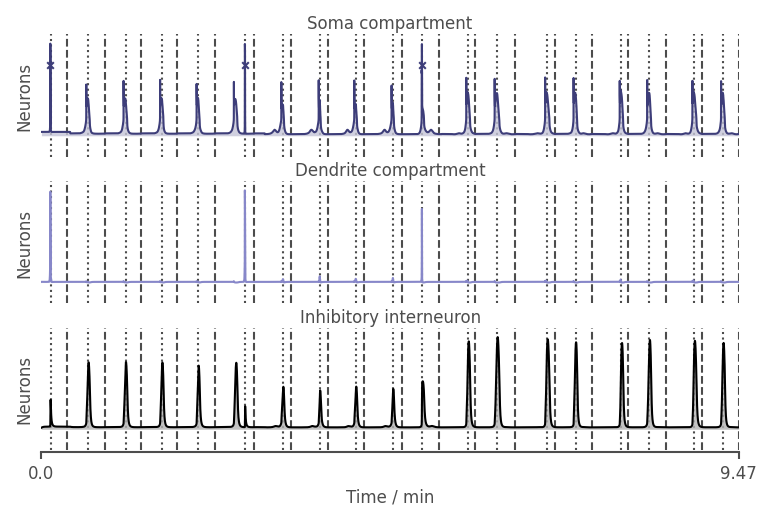

In [24]:
bf_start_time = Ag.t
BF_NUM_STEPS = int(NUM_STEPS * 2)

learner_bf = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=BF_NUM_STEPS,
    reverse=True,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_bf.Pyrs)
ts_axes = learner_bf.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["3-back_forth_time"] = time_axes
ALL_FIGURES["3-back_forth_timeseries"] = ts_axes

### Back and forth track groundtruth rate maps

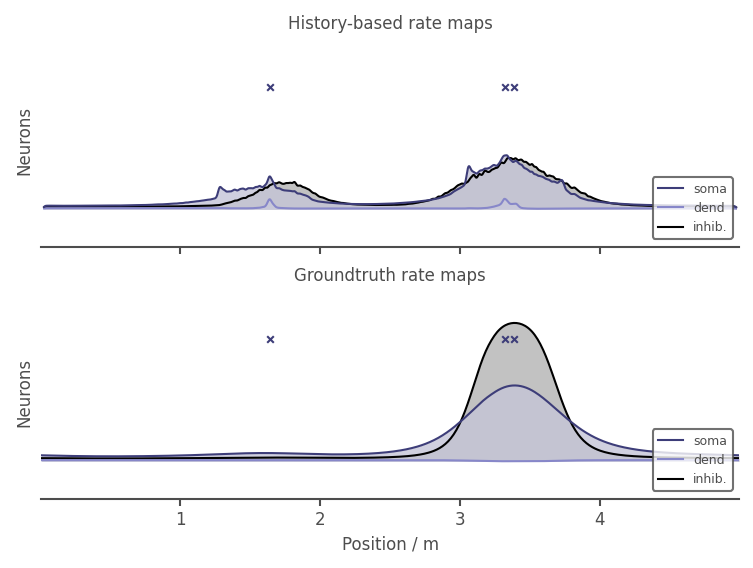

In [25]:
fig, ax1D = plt.subplots(nrows=2, figsize=[6, 4], sharex=True)
learner_bf.Pyrs.plot_rate_map(ax=ax1D[0], compartment="all", method="history")
ax1D[0].set_title("History-based rate maps")
ax1D[0].set_xlabel("")
learner_bf.Pyrs.plot_rate_map(ax=ax1D[1], compartment="all", max_recurrence=1)
ax1D[1].set_title("Groundtruth rate maps")

ALL_FIGURES["3-back_forth_rate_maps"] = ax1D

### Back and forth track BTSP stats

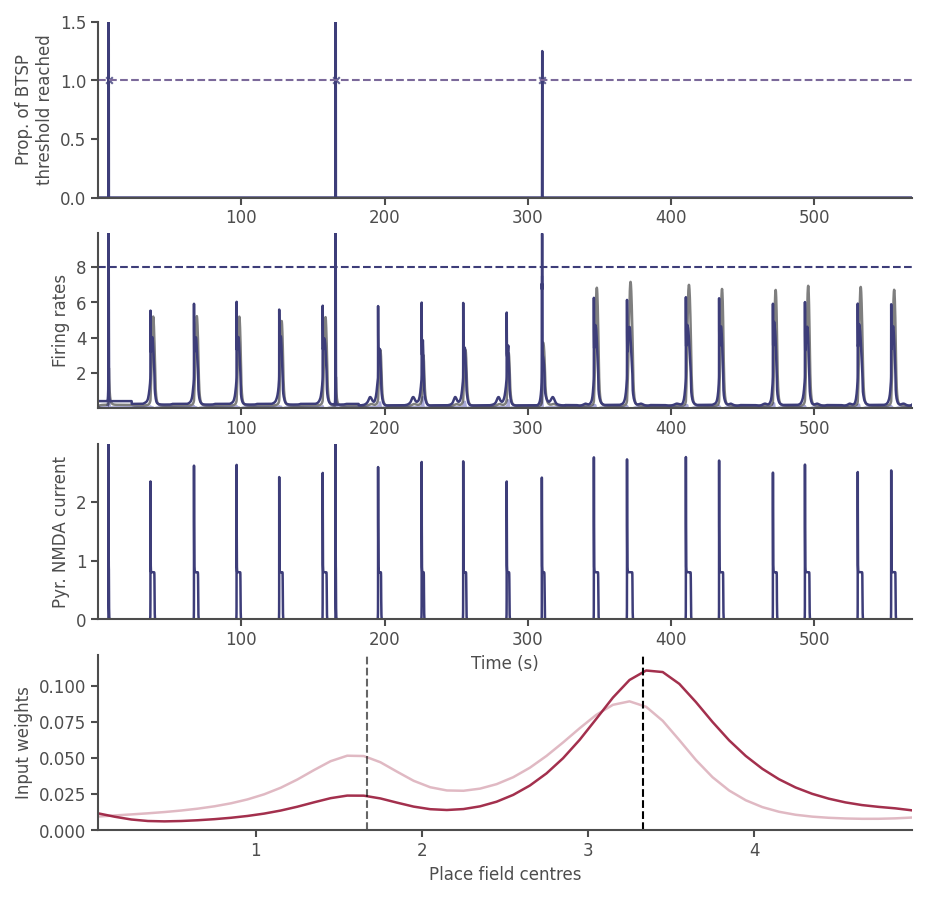

In [26]:
ax1D = plot_fcts.plot_1D_BTSP_stats(
    learner_bf.Pyrs, 
    recorded_weights=learner_bf.get_recorded_weights(),
    target_position=moved_target_position, 
    other_positions=[target_position]
)

ALL_FIGURES["3-back_forth_BTSP_timeseries"] = ax1D

BTSP events applied after 537.00 steps (16.11 sec.) (num steps: 537, 537, 537).


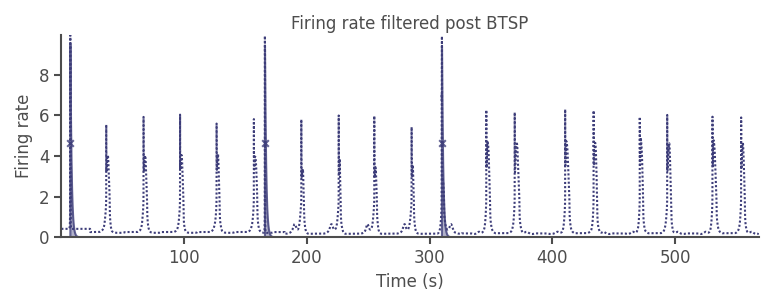

In [27]:
learner_bf.Pyrs.SomaCompartment.log_num_steps_to_apply_BTSP()
sub_ax = learner_bf.Pyrs.SomaCompartment.plot_filtered_for_BTSP()

ALL_FIGURES["3-back_forth_post_BTSP_filter"] = sub_ax

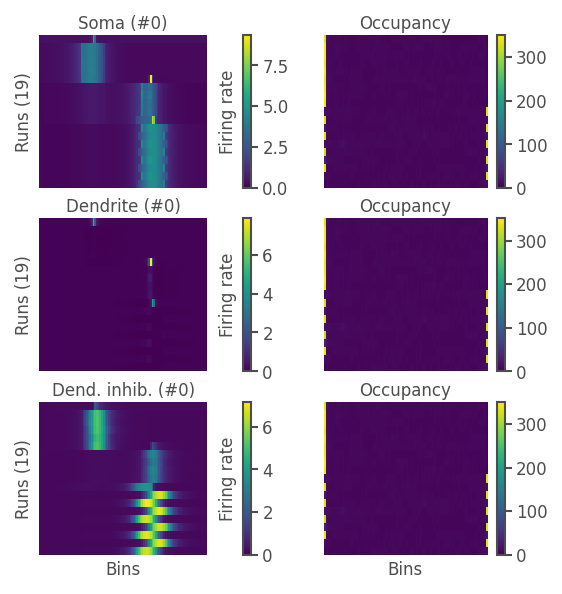

In [28]:
axes = learner_bf.Pyrs.plot_binned_rates()

ALL_FIGURES["3-back_forth_binned_rates"] = axes

## 4. Remove object from track
Object removed from track.

100%|██████████████████████████████████████| 7600/7600 [00:08<00:00, 870.96it/s]


Finishing last trajectory.


547it [00:01, 484.22it/s]


Only reached target 8 times (target: 10).
Trajectory lengths (28) to date: 29.02 +/- 5.91 sec each
Trajectory lengths (28) to date: 967.36 +/- 197.02 steps each
0 BTSP events triggered (allowed from steps 18938 to 27085).

Target removed.


100%|██████████████████████████████████████| 3800/3800 [00:04<00:00, 928.88it/s]


Finishing last trajectory.


275it [00:00, 923.41it/s]


Only reached target 0 times (target: 10).
Trajectory lengths (32) to date: 29.21 +/- 5.55 sec each
Trajectory lengths (32) to date: 973.81 +/- 185.09 steps each
0 BTSP events triggered (allowed from steps 27086 to 31161).


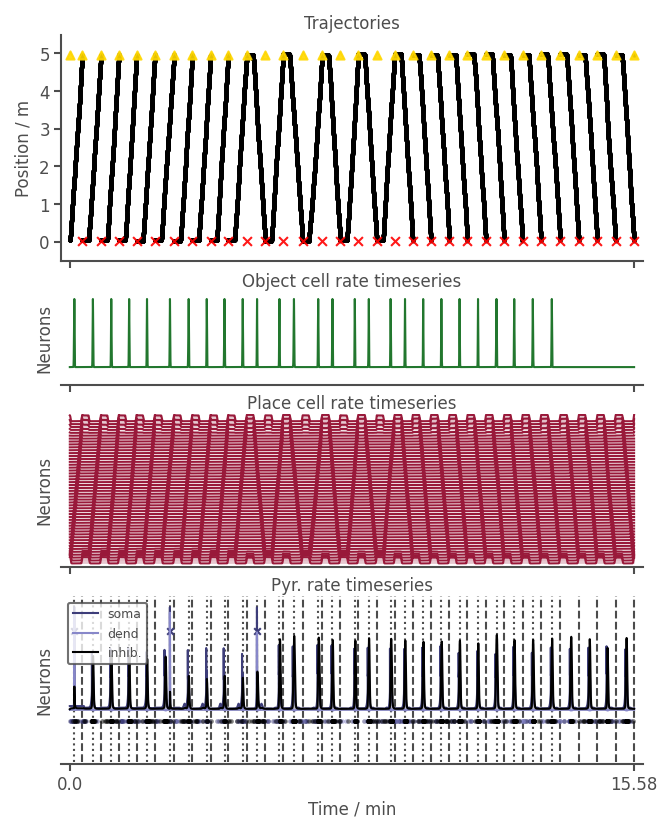

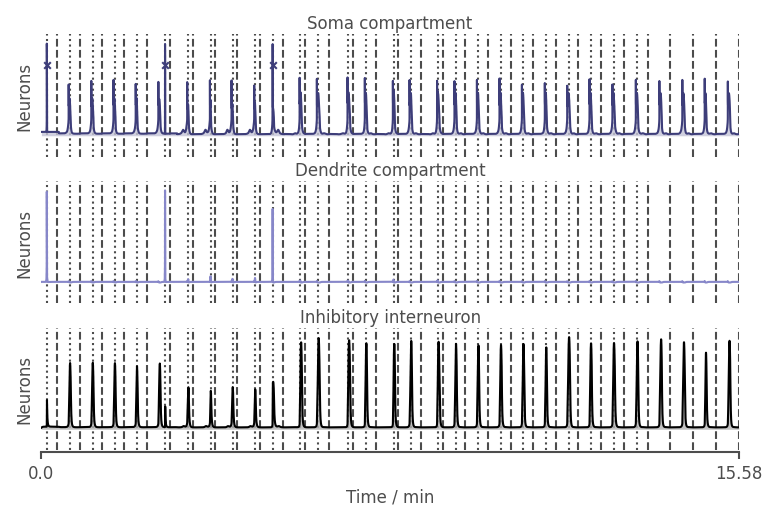

In [29]:
pre_removed_time = Ag.t
learner_pre_removed = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    num_trajectories=4,
    max_num_steps=NUM_STEPS * 2, # excess
    plot=False
)

print("\nTarget removed.")
Ag.set_target_position(None)
Objs.set_to_dummy()
removed_time = Ag.t
        
learner_post_removed = run_manager.learn_1D_BTSP(
    Pyrs=Pyrs,
    use_Hebbian=USE_HEBBIAN,
    BTSP_on=0,
    max_num_steps=NUM_STEPS,
    plot=False
)

time_axes = plot_fcts.plot_1D_time_info(learner_post_removed.Pyrs)
ts_axes = learner_post_removed.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

ALL_FIGURES["4-removed_time"] = time_axes
ALL_FIGURES["4-removed_timeseries"] = ts_axes

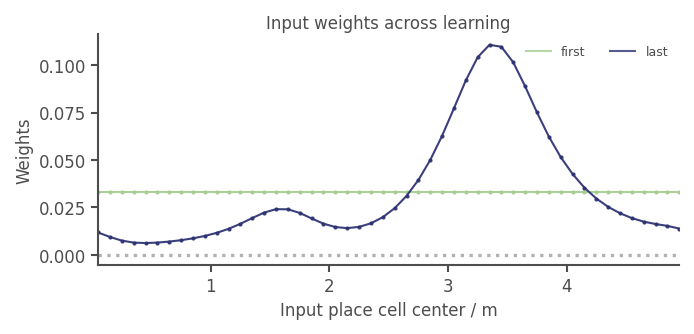

In [30]:
ws = [Pyrs.SomaCompartment.inputs["PCs"][key] for key in ["w_init", "w"]]
sub_ax = plot_fcts.plot_1D_input_place_cell_weights(ws, Pyrs.SomaCompartment.inputs["PCs"]["layer"])

ALL_FIGURES["4-removed_weights"] = sub_ax

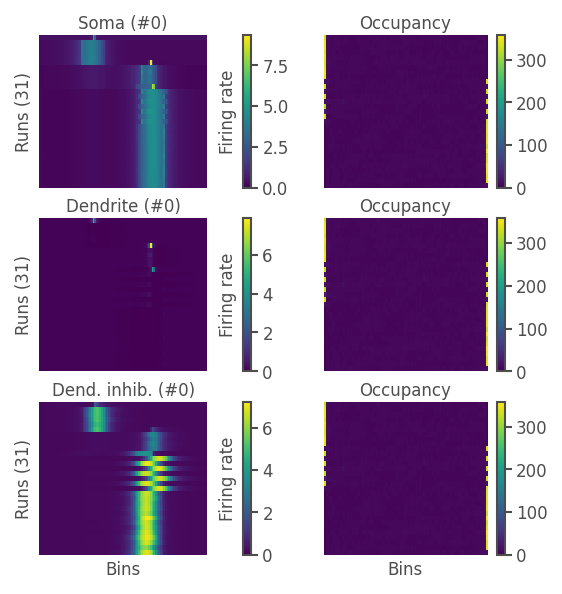

In [31]:
axes = Pyrs.plot_binned_rates()

ALL_FIGURES["4-removed_binned_rates"] = axes

## Before / After

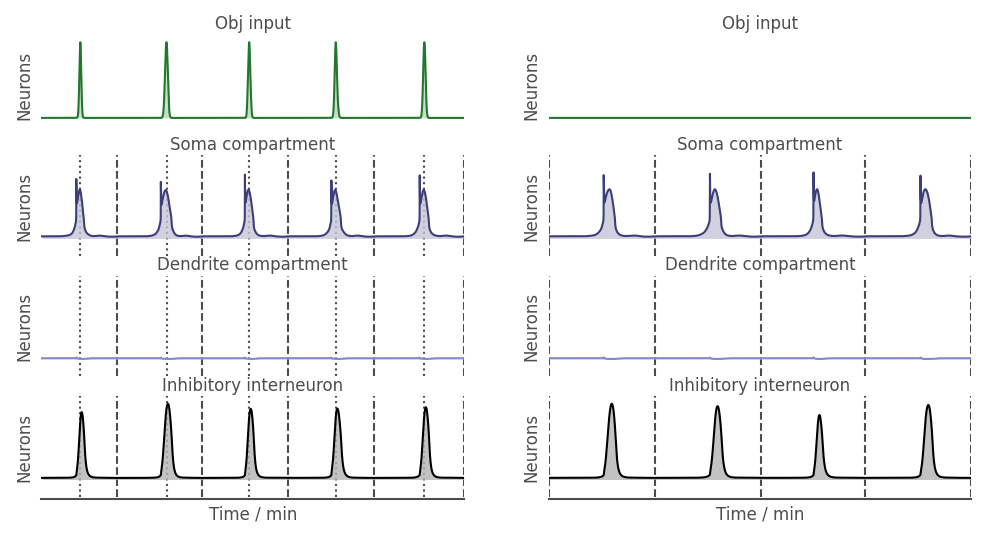

In [32]:
axes = plot_fcts.plot_pre_post_responses(Pyrs, Objs, ref_time=removed_time, pre=2.5 * 60)
ALL_FIGURES["4-removed_pre_post"] = axes

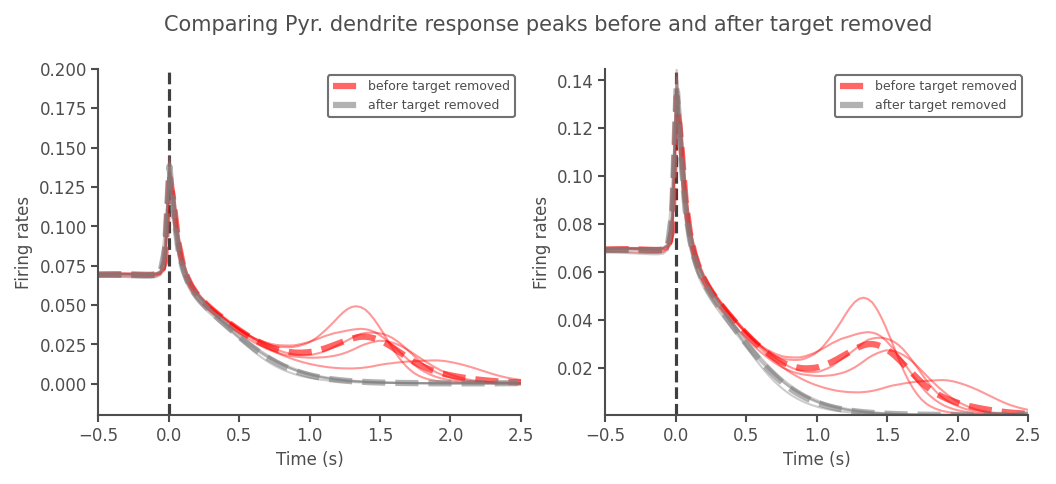

In [33]:
fig, ax1D = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=False)

pre = 2.5 * 60
pts_btw = 100
all_ylims = [(-0.02, 0.2), None]

for i, ylims in enumerate(all_ylims):
    plot_fcts.plot_pre_post_dendrite_peaks(
        Pyrs, 
        ref_time=removed_time, 
        pre=pre,
        ylims=ylims,
        together=True, 
        label="target removed", 
        ax=ax1D[i],
        pts_btw=pts_btw
    )

ALL_FIGURES["4-removed_pre_post_dendrite"] = ax1D

## 6. Change running speed

In [34]:
def get_speed(speed="slow"):
    
    base_num_steps = NUM_STEPS * 4
    if speed == "slow":
        speed_mean = params_util.SPEED_MEAN_LINEAR / 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 8
        num_steps_use = int(base_num_steps * 1.5)
    elif speed == "fast":
        speed_mean = params_util.SPEED_MEAN_LINEAR * 1.5
        speed_std = params_util.SPEED_MEAN_LINEAR / 16
        num_steps_use = int(base_num_steps / 1.5)
    elif speed == "variable":
        speed_mean = params_util.SPEED_MEAN_LINEAR
        speed_std = params_util.SPEED_MEAN_LINEAR
        num_steps_use = base_num_steps
    else:
        raise ValueError(f"speed {speed} not recognized.")

    return speed_mean, speed_std, num_steps_use

Running at slow speed.


100%|████████████████████████████████████| 22800/22800 [00:28<00:00, 794.62it/s]


Finishing last trajectory.


61it [00:00, 851.56it/s]


Only reached target 15 times (target: 16).
Trajectory lengths (16) to date: 42.87 +/- 11.66 sec each
Trajectory lengths (16) to date: 1428.88 +/- 388.53 steps each
1 BTSP events triggered (allowed from steps 0 to 22861): occurred at step 559.
Speed mean: 16.05 cm/s, std: 3.55 cm/s.

Running at fast speed.


...

Only reached target 11 times (target: 16).
Trajectory lengths (12) to date: 26.03 +/- 8.98 sec each
Trajectory lengths (12) to date: 867.58 +/- 299.25 steps each
1 BTSP events triggered (allowed from steps 0 to 10410): occurred at step 243.
Speed mean: 35.74 cm/s, std: 5.57 cm/s.

Running at variable speed.


100%|████████████████████████████████████| 15200/15200 [00:19<00:00, 766.07it/s]


Finishing last trajectory.


385it [00:00, 898.09it/s]


Only reached target 15 times (target: 16).
Trajectory lengths (16) to date: 29.22 +/- 8.54 sec each
Trajectory lengths (16) to date: 974.12 +/- 284.80 steps each
1 BTSP events triggered (allowed from steps 0 to 15585): occurred at step 284.
Speed mean: 30.75 cm/s, std: 19.42 cm/s.


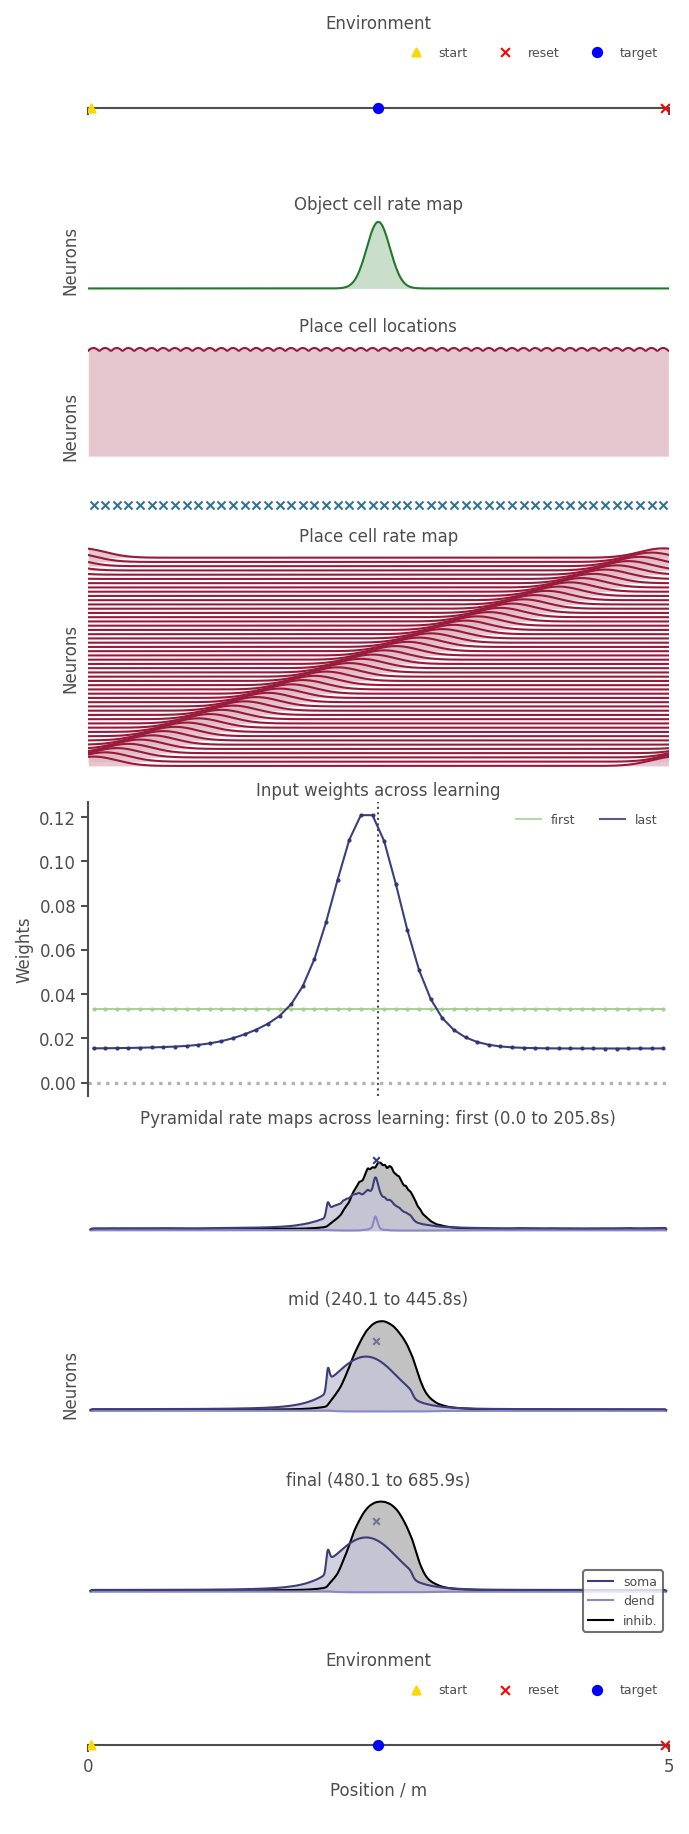

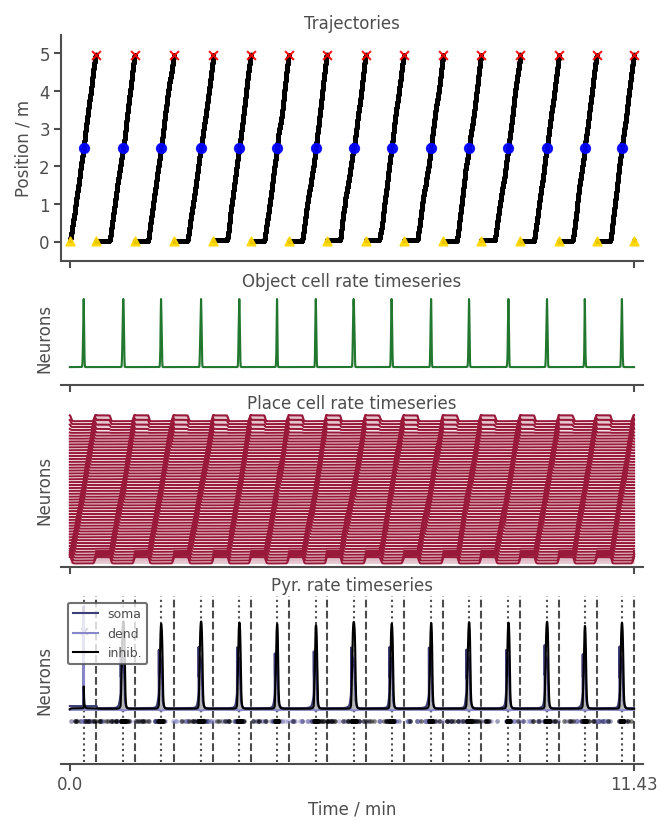

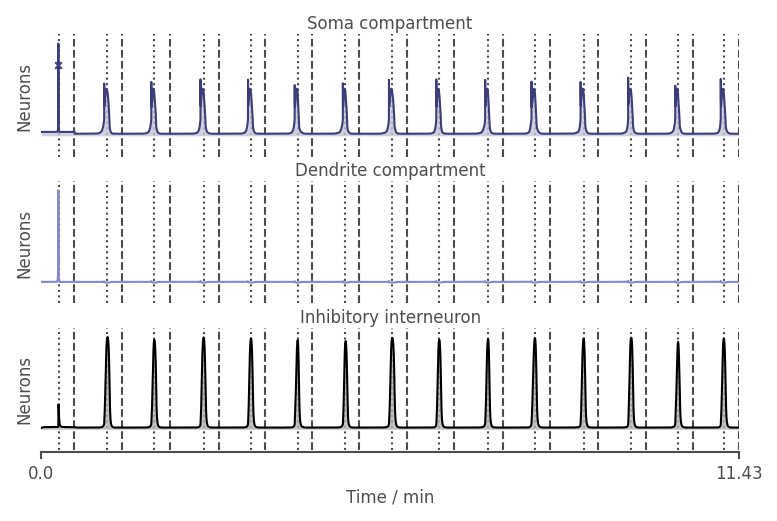

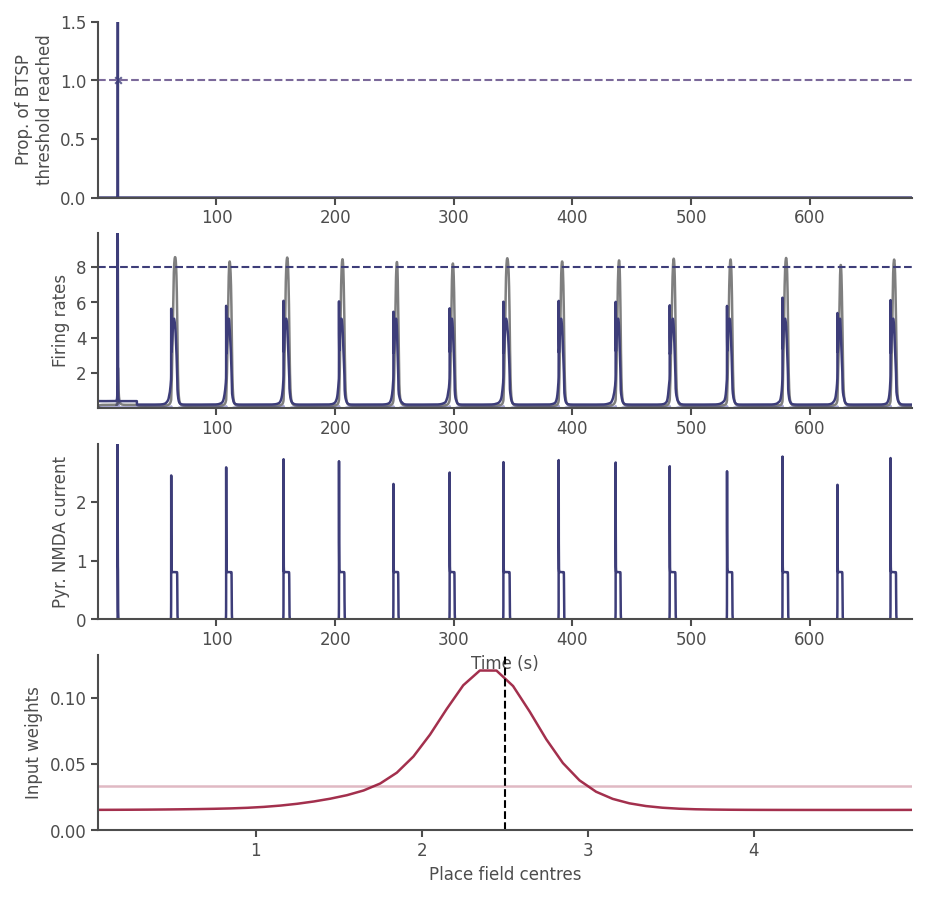

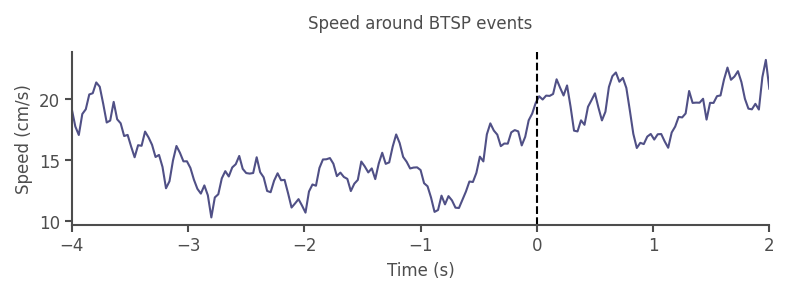

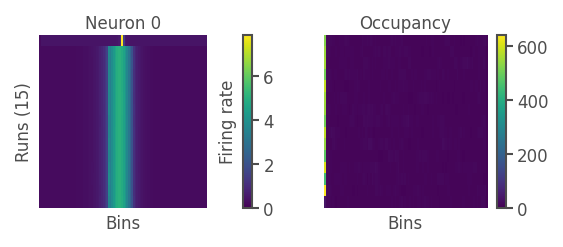

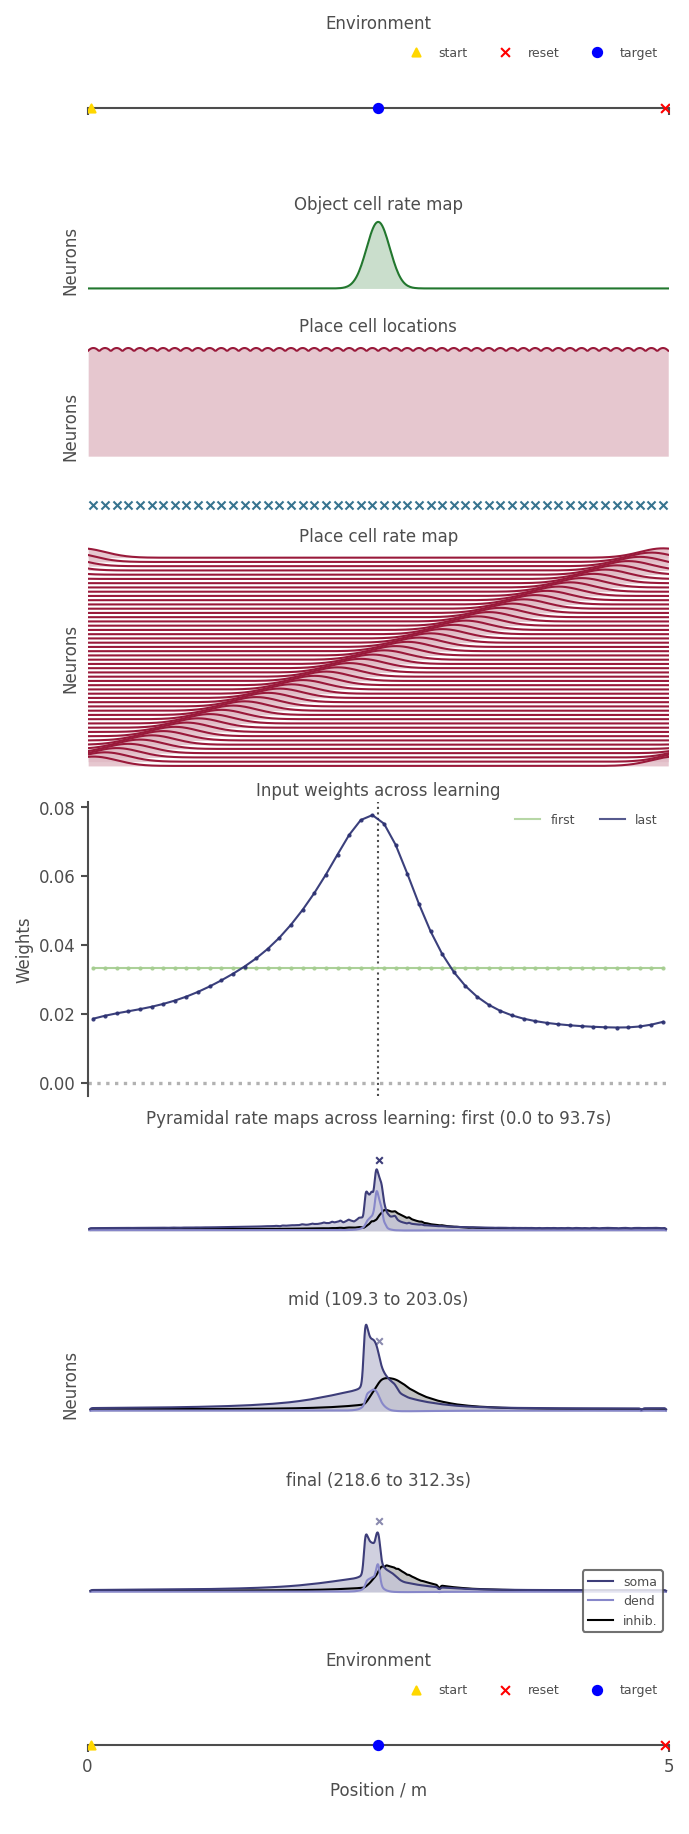

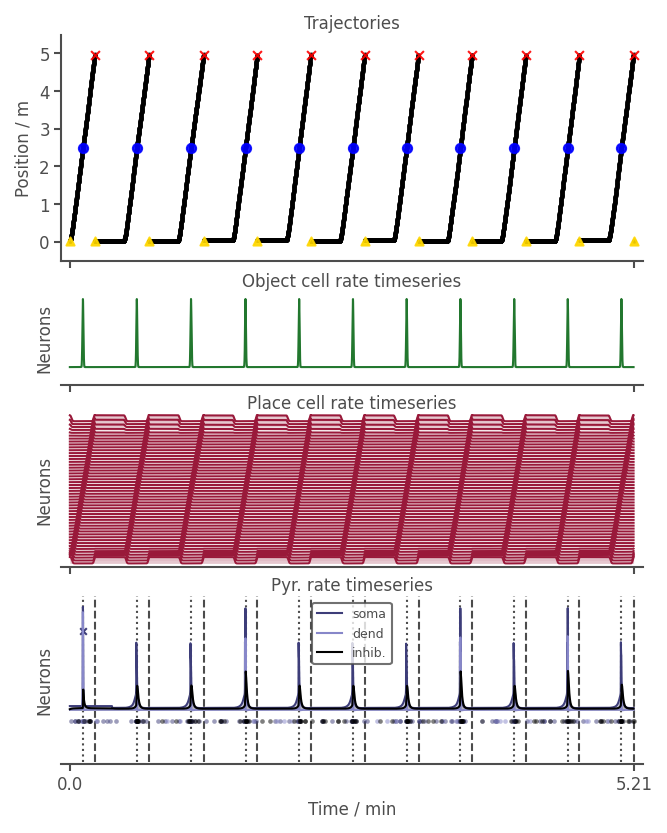

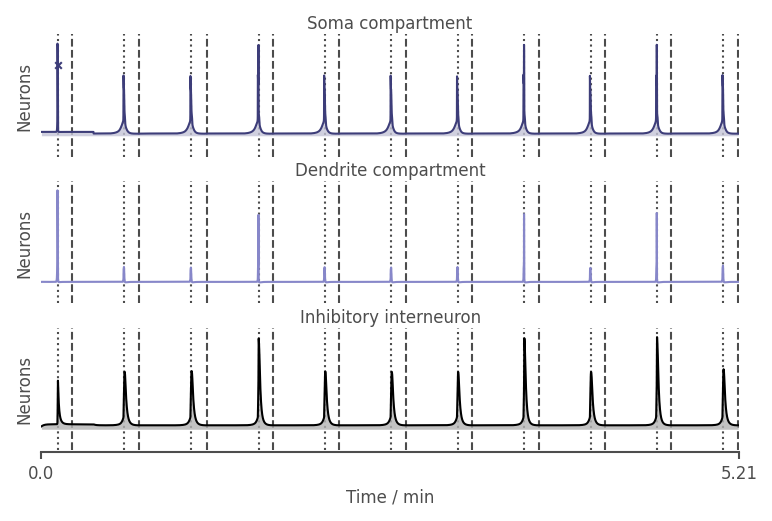

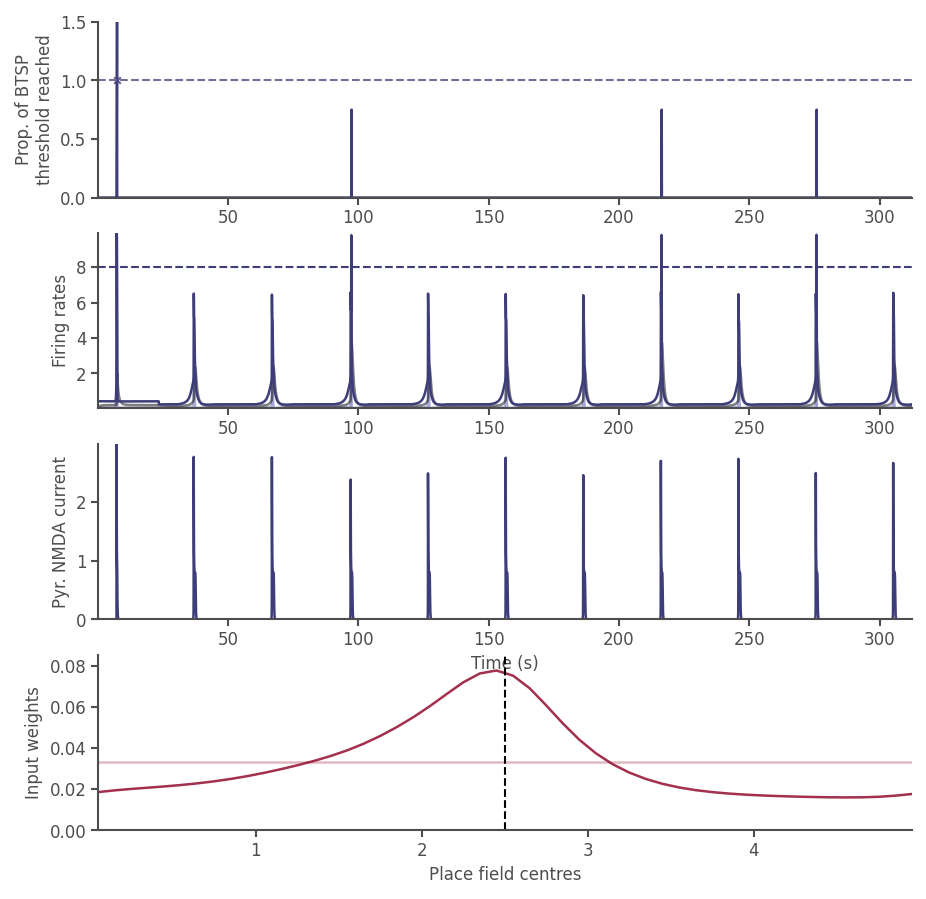

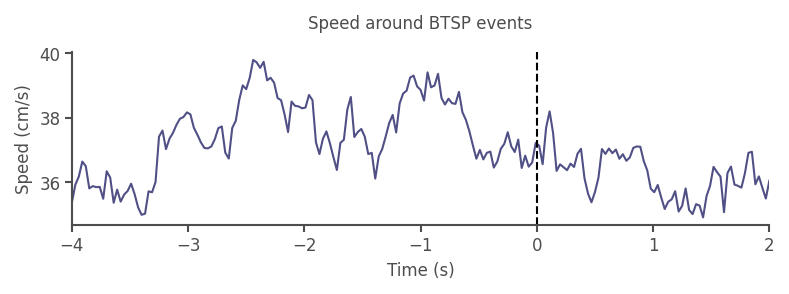

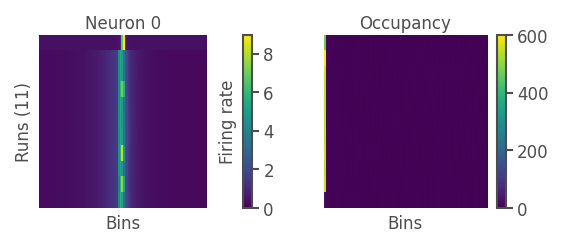

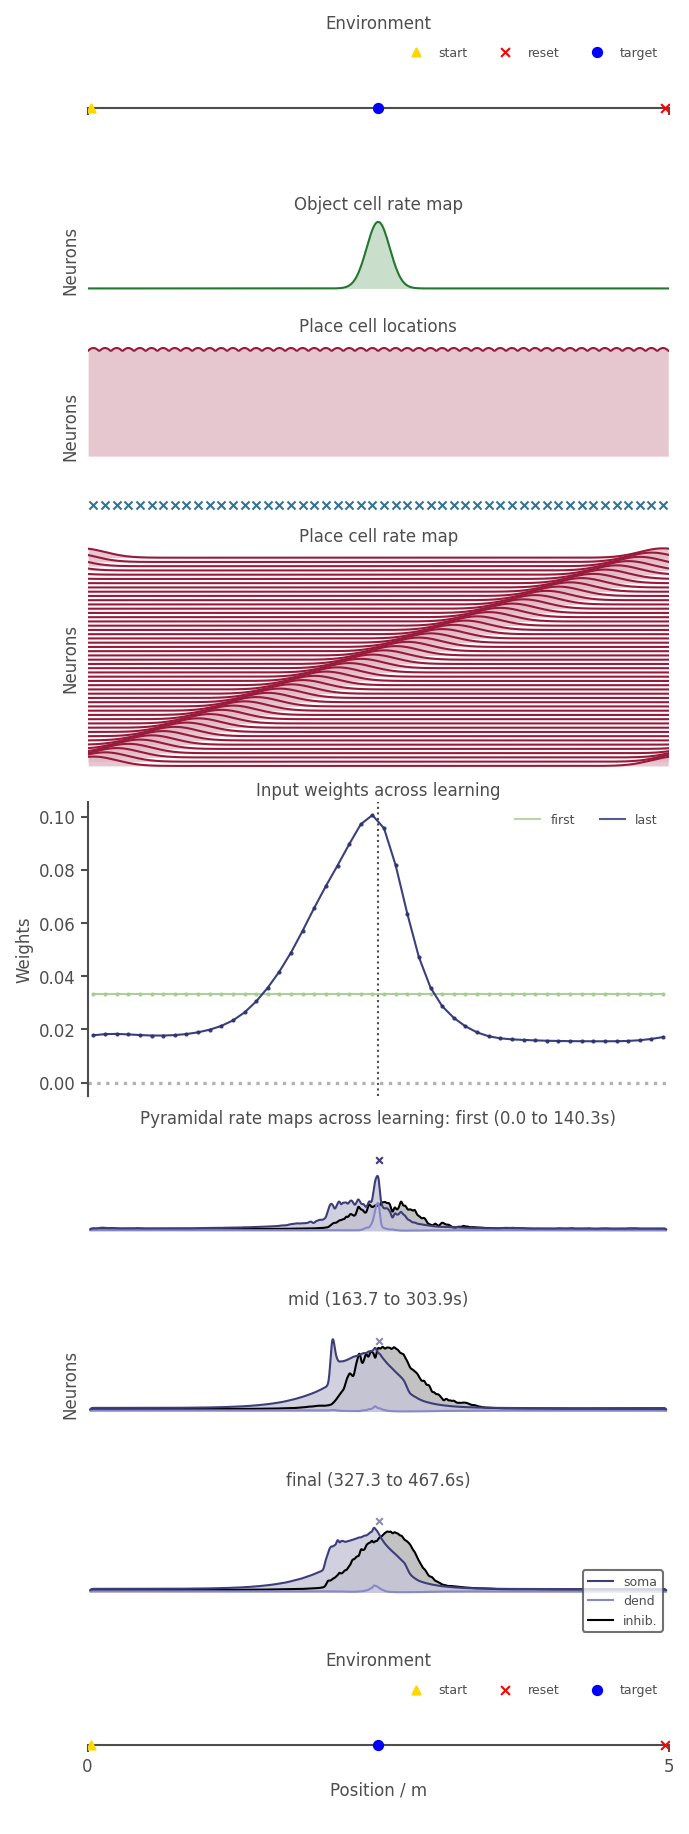

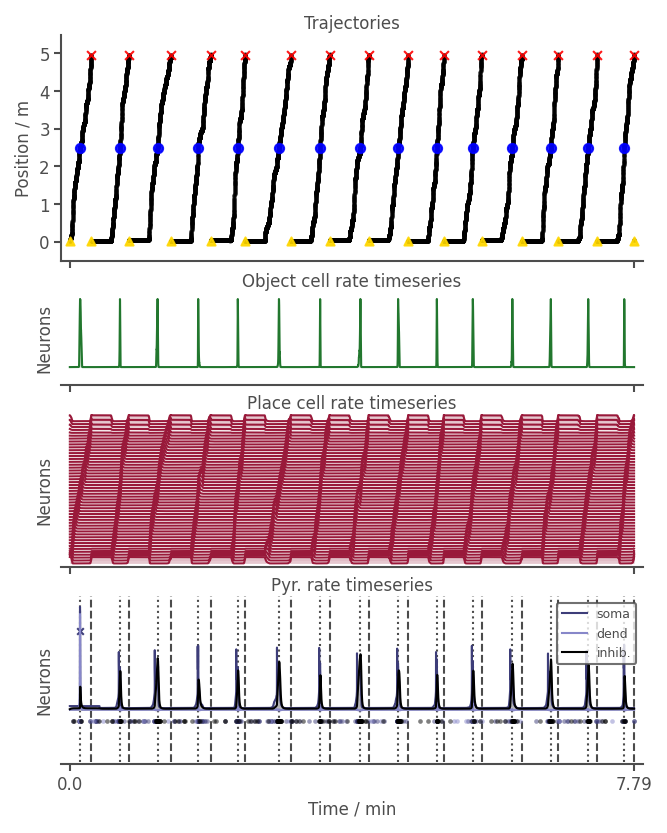

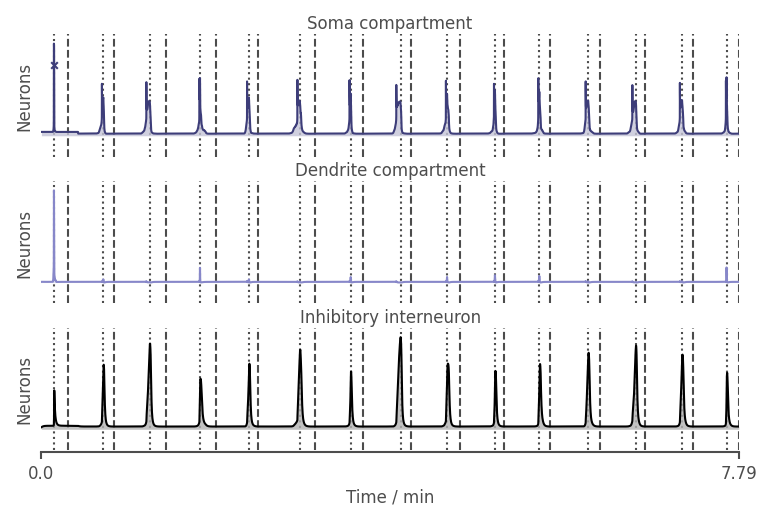

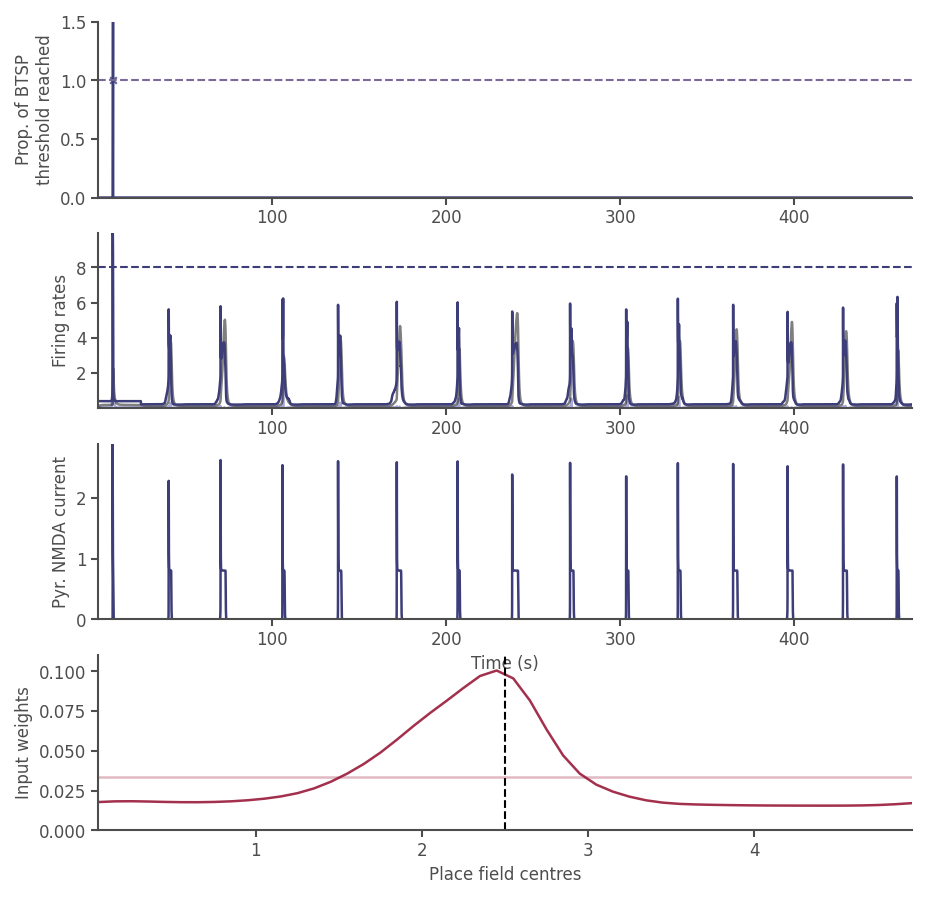

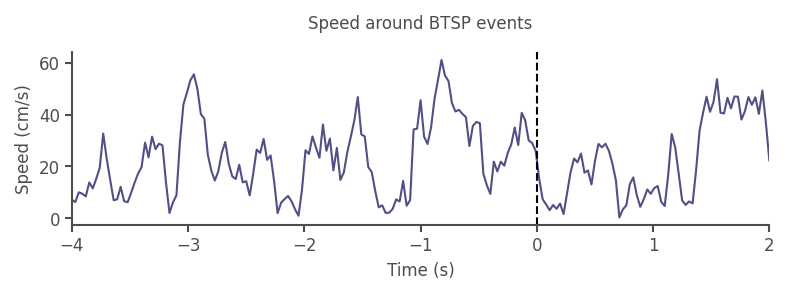

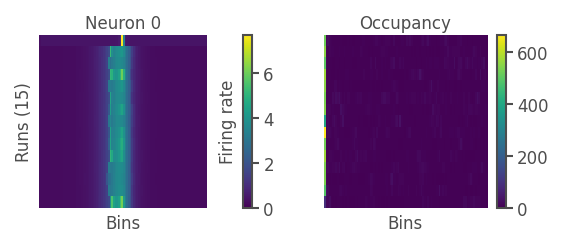

In [46]:
speed_learners_all = list()
for i, speed in enumerate(["slow", "fast", "variable"]):
    space = "\n" if i > 0 else ""
    print(f"{space}Running at {speed} speed.")

    speed_mean, speed_std, num_steps_use = get_speed(speed)
    speed_target_position = np.asarray([params_util.SCALE_LINEAR / 2])
    agent_params_speed = params_util.get_agent_params(
        environment="linear",
        target_position=speed_target_position,
        speed_mean=speed_mean,
        speed_std=speed_std,
    )
    
    speed_learner, spatial_axes_speed, time_axes_speed = run_manager.learn_1D_BTSP(
        agent_params=agent_params_speed,
        Pyr_params=Pyr_params,
        use_Hebbian=USE_HEBBIAN,
        BTSP_on=0,
        max_num_steps=num_steps_use,
        num_target_reaches=16,
    )
    speed_learners_all.append(speed_learner)
    
    speed_learner.Agent.log_speed_stats(ignore_near_zero=True)
    
    ts_axes_speed = speed_learner.Pyrs.plot_rate_timeseries(separate_axes=True, Pyrs_norm_by="shared_max")

    BTSP_stats_ax1D_speed = plot_fcts.plot_1D_BTSP_stats(
        speed_learner.Pyrs, 
        recorded_weights=speed_learner.get_recorded_weights(), 
        target_position=speed_target_position
    )

    BTSP_speed_sub_ax = speed_learner.Pyrs.SomaCompartment.plot_around_BTSP(datatype="speed")

    binned_rates_axes = speed_learner.Pyrs.SomaCompartment.plot_binned_rates(vel_sign_smooth=39) # high threshold

    ALL_FIGURES[f"5-spatial_{speed}"] = spatial_axes_speed
    ALL_FIGURES[f"5-time_{speed}"] = time_axes_speed
    ALL_FIGURES[f"5-timeseries_{speed}"] = ts_axes_speed
    ALL_FIGURES[f"5-BTSP_stats_{speed}"] = BTSP_stats_ax1D_speed
    ALL_FIGURES[f"5-BTSP_speed_{speed}"] = BTSP_speed_sub_ax
    ALL_FIGURES[f"5-binned_rates_{speed}"] = binned_rates_axes

## 7. Save and animate

### Save figures

In [47]:
SAVE = True

In [37]:
if SAVE:
    print(f"Saving {len(ALL_FIGURES)} figures...")
    for key, ax in ALL_FIGURES.items():
        if isinstance(ax, np.ndarray):
            fig = ax.ravel()[0].figure
        else:
            fig = ax.figure
        plot_util.save_figure(fig, key, save=True)        

Saving 55 figures...
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_spatial_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_time_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_timeseries_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-single_speed_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-single_occupancy_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_rate_maps_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_binned_rates_1452.png  & .svg
Figure saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_weights_1452.png  & .svg
Figure saved to /home/

### Animate

In [38]:
ANIMATE = True

In [39]:
if ANIMATE:
    all_learners = [
        learner, 
        learner_moved, 
        learner_bf, 
        learner_pre_removed, 
        learner_post_removed
    ]

    all_weight_dicts = [curr_learner.get_recorded_weights() for curr_learner in all_learners]
    combined_weights = {
        key: np.concatenate([weight_dict[key] for weight_dict in all_weight_dicts]).tolist() 
        for key in all_weight_dicts[0].keys()
    }
    
    all_animate_kwargs = {
        "Pyrs": Pyrs,
        "Pyrs_weights": combined_weights["weights"],
        "Pyrs_weights_t": combined_weights["time"],
        "fps": 8,
        "speed_up": 3,
        "previous_target_positions": [target_position, moved_target_position],
        "target_move_times": [move_time, removed_time],
        "embed_limit": 40.0,
        "autosave": True,
    }
    
    if (Ag.start_position > Ag.reset_position).all():
        Ag.reverse()

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/1-initial_timeseries_1452.mp4  & .gif
Animation took 5.18 min. to create.


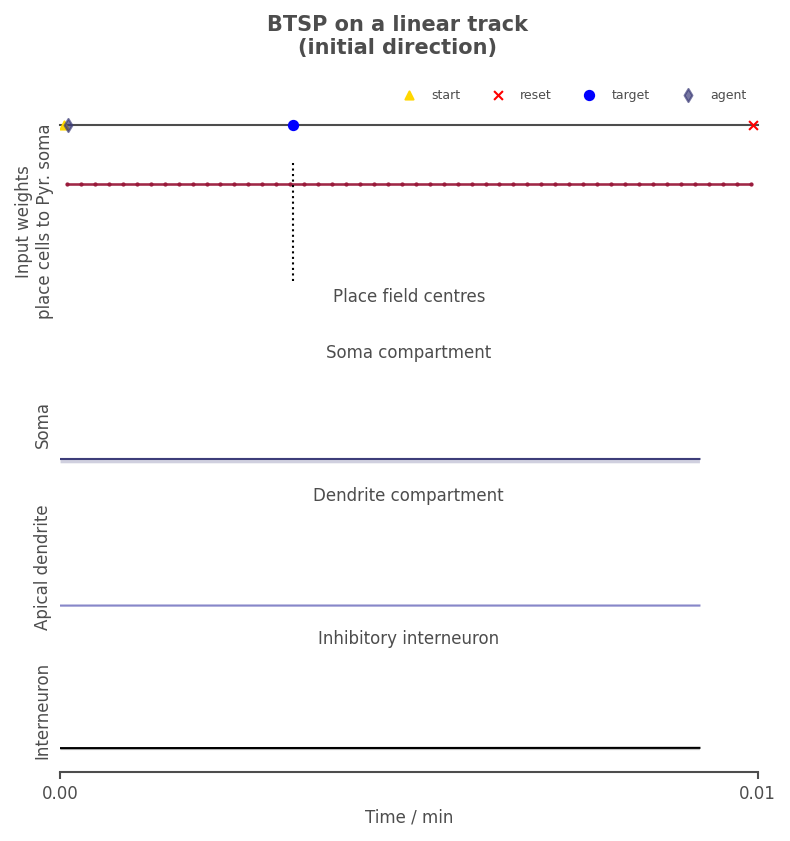

In [40]:
importlib.reload(animate_util)
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=move_time, 
        savename="1-initial_timeseries",
        addendum="initial direction",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/2-moved_timeseries_1458.mp4  & .gif
Animation took 4.62 min. to create.


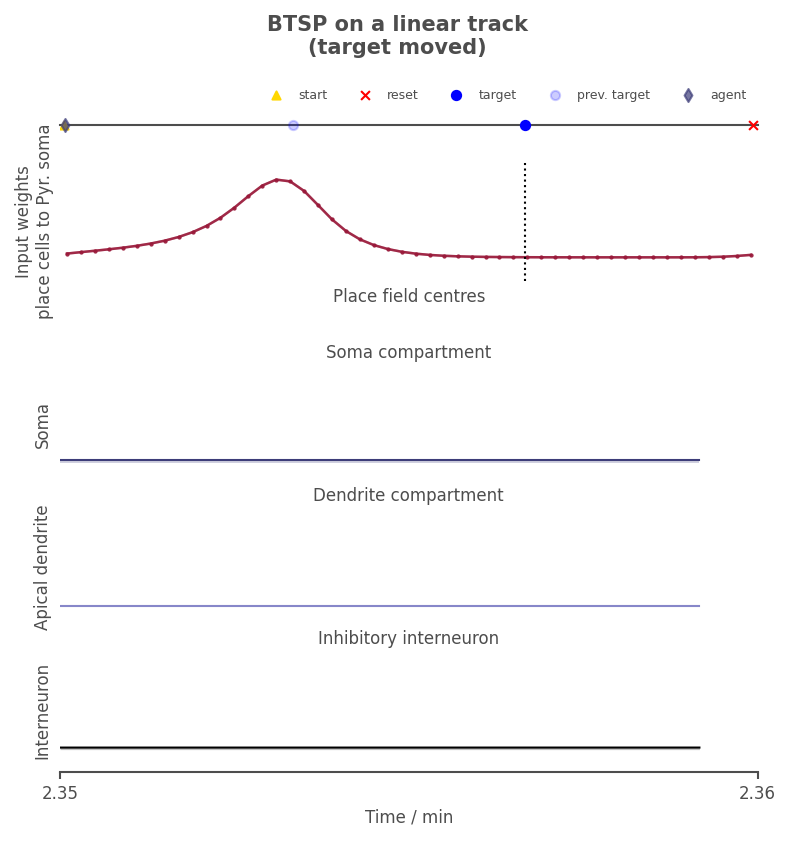

In [41]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=move_time, 
        t_end=bf_start_time, 
        savename="2-moved_timeseries",
        addendum="target moved",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/3-back_forth_timeseries_1502.mp4  & .gif
Animation took 12.15 min. to create.


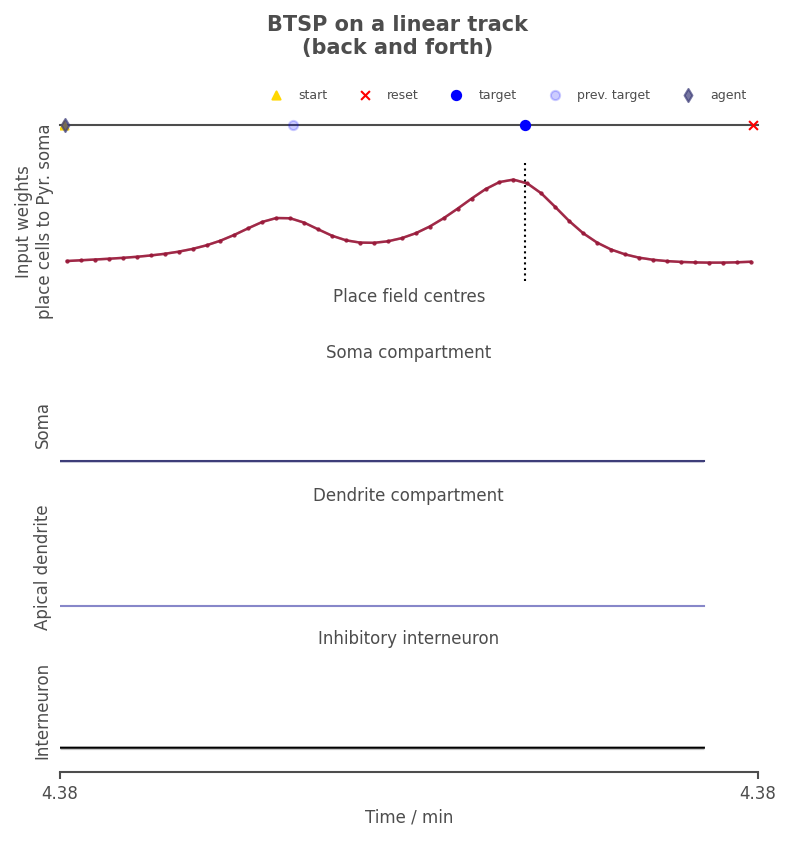

In [42]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=bf_start_time, 
        t_end=pre_removed_time, 
        savename="3-back_forth_timeseries",
        addendum="back and forth",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/4-removed_timeseries_1515.mp4  & .gif
Animation took 15.06 min. to create.


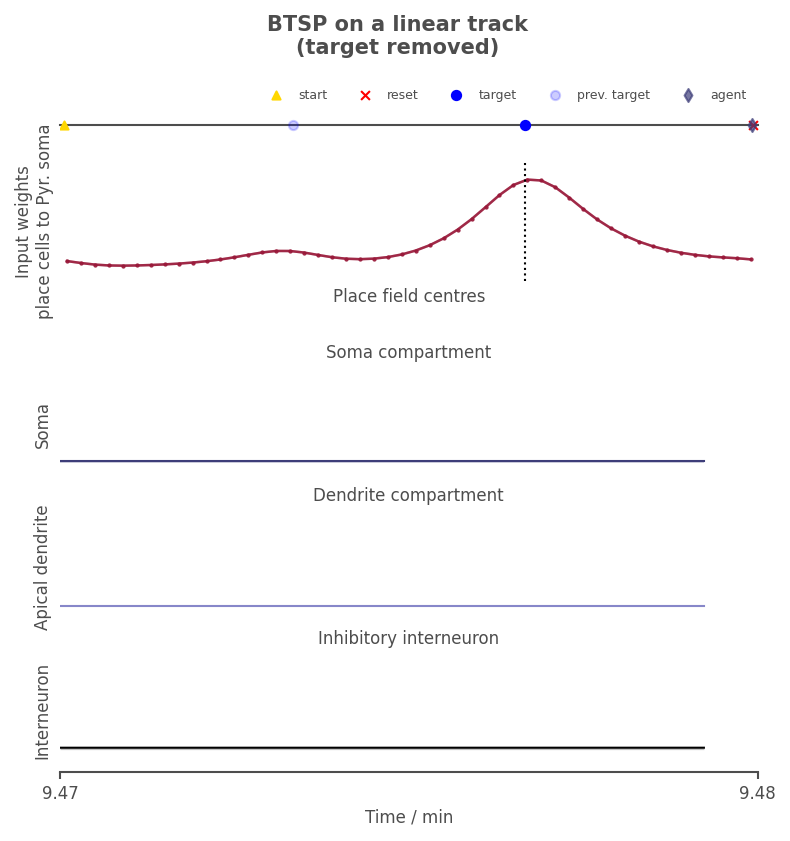

In [43]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=pre_removed_time, 
        t_end=None, 
        savename="4-removed_timeseries",
        addendum="target removed",
        **all_animate_kwargs
        )
    anim

Animation saved to /home/cgillon/homedir/predhpc/scripts/figures/linear_track/25_02_26/5-full_timeseries_1530.mp4  & .gif
Animation took 41.55 min. to create.


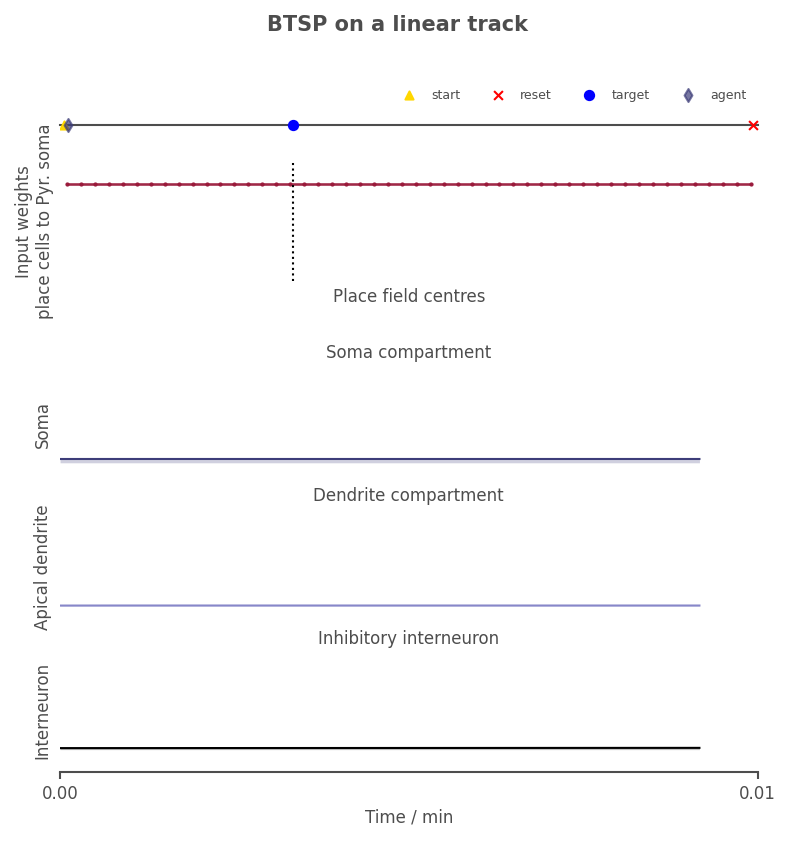

In [44]:
if ANIMATE:
    anim = animate_util.animate(
        t_start=0, 
        t_end=None, 
        savename="5-full_timeseries",
        **all_animate_kwargs
        )
    anim